#***Analiza tržišta automobila u BiH***

#**0. Uvod**
Podaci koji su obrađeni u ovom radu su prikupljeni sa stranice [https://olx.ba/](https://olx.ba/), kao jedne od najpopularnijih stranica za kupovinu i prodaju automobila, većinski polovnih. (Kod koji je korišten za web scraping se nalazi u sljedecem linku: [https://github.com/VedadGastan/VIS-Zadaca-2](https://github.com/VedadGastan/VIS-Zadaca-2)). Cilj ovog rada jeste analiza tržista automobila u BiH, modela, marki, cijena i drugih parametara koji imaju uticaja pri kupovini automobila, te posmatranje raspodijela pojedinih podataka unutar dataset-a.

In [ ]:
# Ucitavanje biblioteka
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import numpy as np
from scipy.stats import t, norm
from scipy import stats
from scipy.stats import chi2, chi2_contingency
from scipy.stats import ttest_ind

from google.colab import drive

drive.mount('/content/drive', force_remount=True)

df0 = pd.read_csv('/content/drive/MyDrive/datasets/data.csv')

Mounted at /content/drive


#**1. Čišćenje podataka**

Pogledajmo prvo generalni izgled i potencijalne nepravilnosti u podacima.

In [ ]:
# Provjer izgleda dataseta
df0.head(10)

,Stanje,Pregledi,Cijena,Proizvodjac,Model,Gorivo,Godiste,Transmisija,Kilometraza,Kubikaza,Snaga motora (KW),Broj vrata
0,Koristeno,90.0,14000.0,Mercedes-Benz,C 200,Dizel,2010.0,Manuelni,290000,2.2,100.0,4/5
1,Koristeno,239.0,8600.0,Seat,Altea XL,Dizel,2007.0,Manuelni,265000,1.9,77.0,4/5
2,Koristeno,14529.0,44900.0,Volkswagen,Tiguan,Dizel,2016.0,Automatik,217000,2.0,110.0,4/5
3,Koristeno,7215.0,10900.0,Opel,Astra,Dizel,2011.0,Manuelni,199856,1.7,81.0,4/5
4,Koristeno,5535.0,NaN,Volkswagen,Touareg,Dizel,2011.0,Automatik,160000,3.0,180.0,4/5
5,Koristeno,8031.0,27800.0,Volkswagen,Passat,Dizel,2017.0,Automatik,250000,2.0,110.0,4/5
6,Koristeno,38495.0,84500.0,Volkswagen,Amarok,Dizel,2016.0,Automatik,230000,3.0,165.0,4/5
7,Koristeno,48.0,7850.0,Seat,Ibiza,Dizel,2011.0,Manuelni,226453,1.2,55.0,4/5
8,Koristeno,18492.0,19990.0,Audi,A6,Dizel,2010.0,Automatik,280000,2.7,140.0,4/5
9,Koristeno,4412.0,13900.0,Audi,A3,Dizel,2011.0,Manuelni,223456,1.6,77.0,4/5


In [ ]:
df0.describe()

,Pregledi,Godiste,Kilometraza,Kubikaza,Snaga motora (KW)
count,2.312000e+03,2318.000000,2.318000e+03,2318.000000,2318.000000
mean,2.675124e+04,2012.947368,2.134185e+05,1.978602,115.547972
std,1.100968e+06,5.412847,2.273914e+05,0.589448,234.432244
min,1.700000e+01,1965.000000,0.000000e+00,0.600000,0.000000
25%,5.977500e+02,2010.000000,1.658350e+05,1.600000,77.000000
50%,1.695000e+03,2012.000000,2.200000e+05,2.000000,103.000000
75%,4.585500e+03,2017.000000,2.600000e+05,2.000000,130.000000
max,5.294113e+07,2024.000000,9.238000e+06,6.500000,11111.000000


Evidentno postoje značajni eksterimi u dataset-u, koje ćemo izbaciti na kraju čišćenja.

In [ ]:
df0.shape[0]

2318

In [ ]:
#Koje varijable imamo i koji im je tip
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2318 entries, 0 to 2317
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Stanje             2318 non-null   object 
 1   Pregledi           2312 non-null   float64
 2   Cijena             1960 non-null   object 
 3   Proizvodjac        2318 non-null   object 
 4   Model              2311 non-null   object 
 5   Gorivo             2318 non-null   object 
 6   Godiste            2318 non-null   float64
 7   Transmisija        2305 non-null   object 
 8   Kilometraza        2318 non-null   int64  
 9   Kubikaza           2318 non-null   float64
 10  Snaga motora (KW)  2318 non-null   float64
 11  Broj vrata         2318 non-null   object 
dtypes: float64(4), int64(1), object(7)
memory usage: 217.4+ KB


Vidimo da postoje određene kolone koje sadrže null vrijednosti. Cijena je očekivano da ih sadrži zbog načina prikupljanja podataka (null označava da je cijena bila "Na upit"), te ćemo pri analizi cijene samo morati zanemariti kolone sa null vrijednostima. Ostale redove sa null vrijednostima ćemo jednostavno izbrisati, posto ih nema mnogo. Prije brisanja pogledajmo još neke druge kolone.

In [ ]:
df0["Stanje"].unique()

array(['Koristeno', 'Novo',
       'Obnovljen:\n                                             25.05.2024 u 07:29',
       'Obnovljen:\n                                             25.05.2024 u 10:30',
       'Obnovljen:\n                                             24.05.2024 u 15:10',
       'Sjedinjene Americke Drzave',
       'Obnovljen:\n                                             24.05.2024 u 19:24',
       'Obnovljen:\n                                             23.05.2024 u 18:47',
       'Obnovljen:\n                                             22.05.2024 u 19:22'],
      dtype=object)

In [ ]:
df1 = df0[(df0['Stanje'] == 'Novo') | (df0['Stanje'] == 'Koristeno')]

Provjerimo jesu li kolone "Gorivo" i "Godiste" uredu.

In [ ]:
df1["Gorivo"].unique()

array(['Dizel', 'Elektro', 'Benzin', 'Plin', 'Hibrid'], dtype=object)

In [ ]:
df1["Godiste"].unique()

array([2010., 2007., 2016., 2011., 2017., 2006., 2018., 1998., 2014.,
       2013., 2019., 2015., 2012., 2020., 2009., 2008., 2021., 2001.,
       2002., 2024., 2003., 2005., 2023., 2022., 2004., 1985., 1983.,
       1991., 1993., 2000., 1988., 1999., 1989., 1997., 1995., 1965.,
       1994.])

Kako su ove kolone uredu, obrišimo konačno redove sa null vrijednostima u kolonama 'Pregledi', 'Model' i 'Transmisija'.

In [ ]:
df1 = df1.dropna(subset=['Pregledi', 'Model', 'Transmisija'])

Za kraj, izbacimo 1% vrijednosti koji predstavljaju ekstreme u kolonama 'Kilometraza', 'Kubikaza' i 'Snaga motora (KW)', koje su kolone sa najvećom varijansom.

In [ ]:
percentiles = df1[['Kilometraza', 'Kubikaza', 'Snaga motora (KW)']].quantile([0.01, 0.99])

df = df1[
    (df1['Kilometraza'] >= percentiles.loc[0.01, 'Kilometraza']) & (df1['Kilometraza'] <= percentiles.loc[0.99, 'Kilometraza']) &
    (df1['Kubikaza'] >= percentiles.loc[0.01, 'Kubikaza']) & (df1['Kubikaza'] <= percentiles.loc[0.99, 'Kubikaza']) &
    (df1['Snaga motora (KW)'] >= percentiles.loc[0.01, 'Snaga motora (KW)']) & (df1['Snaga motora (KW)'] <= percentiles.loc[0.99, 'Snaga motora (KW)'])
]

print(df.shape[0])
print(df.describe())

2208
           Pregledi      Godiste    Kilometraza     Kubikaza  \
count   2208.000000  2208.000000    2208.000000  2208.000000   
mean    3646.197011  2013.072011  206131.182065     1.947237   
std     5340.461812     5.171265   77672.782389     0.494227   
min       17.000000  1965.000000       0.000000     1.000000   
25%      592.000000  2010.000000  168000.000000     1.600000   
50%     1671.000000  2012.000000  220000.000000     2.000000   
75%     4408.250000  2017.000000  259000.000000     2.000000   
max    62223.000000  2024.000000  380000.000000     4.000000   

       Snaga motora (KW)  
count        2208.000000  
mean          108.610054  
std            43.038403  
min            44.000000  
25%            77.000000  
50%           103.000000  
75%           130.000000  
max           310.000000  


In [ ]:
df.head()

,Stanje,Pregledi,Cijena,Proizvodjac,Model,Gorivo,Godiste,Transmisija,Kilometraza,Kubikaza,Snaga motora (KW),Broj vrata
0,Koristeno,90.0,14000.0,Mercedes-Benz,C 200,Dizel,2010.0,Manuelni,290000,2.2,100.0,4/5
1,Koristeno,239.0,8600.0,Seat,Altea XL,Dizel,2007.0,Manuelni,265000,1.9,77.0,4/5
2,Koristeno,14529.0,44900.0,Volkswagen,Tiguan,Dizel,2016.0,Automatik,217000,2.0,110.0,4/5
3,Koristeno,7215.0,10900.0,Opel,Astra,Dizel,2011.0,Manuelni,199856,1.7,81.0,4/5
4,Koristeno,5535.0,NaN,Volkswagen,Touareg,Dizel,2011.0,Automatik,160000,3.0,180.0,4/5


Konačno smo očistili dataset, te prelazimo na analizu.

# **2. Deskriptivna analiza i vizualizacija kolona dataset-a**

##2.1. Stanje

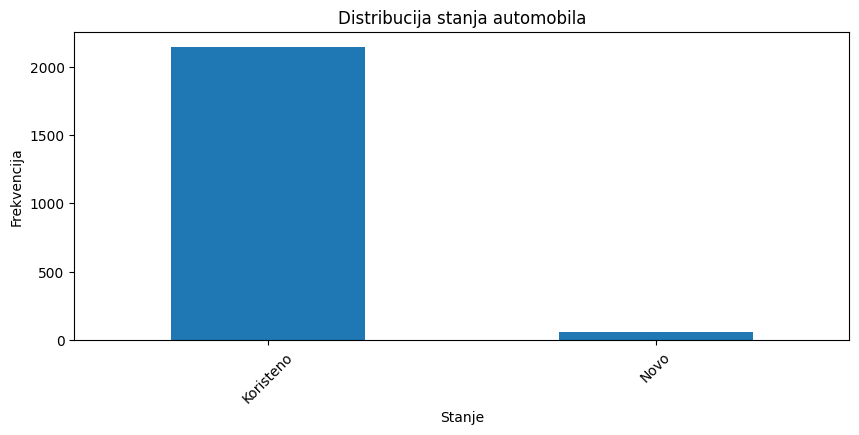

In [ ]:
value_counts = df['Stanje'].value_counts()

value_counts.plot(kind='bar', figsize=(10, 4))
plt.title('Distribucija stanja automobila')
plt.xlabel('Stanje')
plt.ylabel('Frekvencija')
plt.xticks(rotation=45)
plt.show()

Iz grafika jasno vidimo da su automobili postavljeni na olx.ba većinski već korišteni.

##2.2. Pregledi

In [ ]:
df['Pregledi'].describe()

count     2208.000000
mean      3646.197011
std       5340.461812
min         17.000000
25%        592.000000
50%       1671.000000
75%       4408.250000
max      62223.000000
Name: Pregledi, dtype: float64

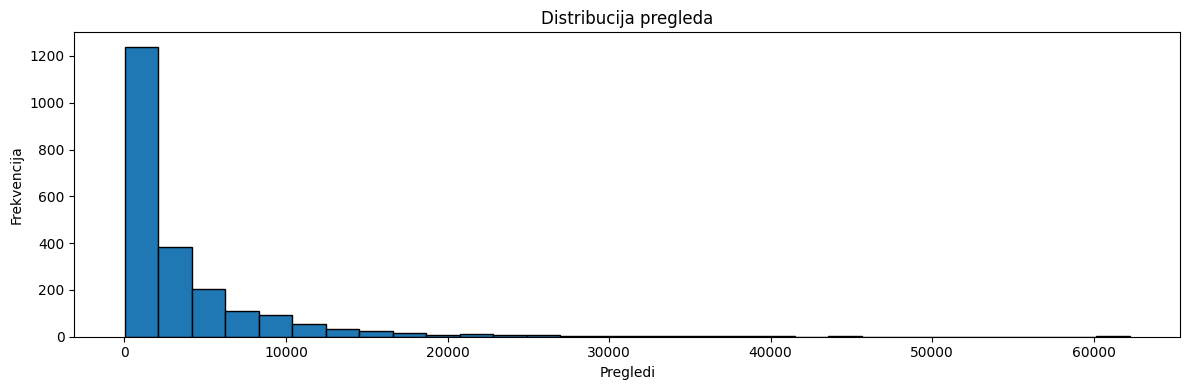

In [ ]:
plt.figure(figsize=(12, 4))

plt.hist(df['Pregledi'], bins=30, edgecolor='k')
plt.title('Distribucija pregleda')
plt.xlabel('Pregledi')
plt.ylabel('Frekvencija')
plt.tight_layout()
plt.show()

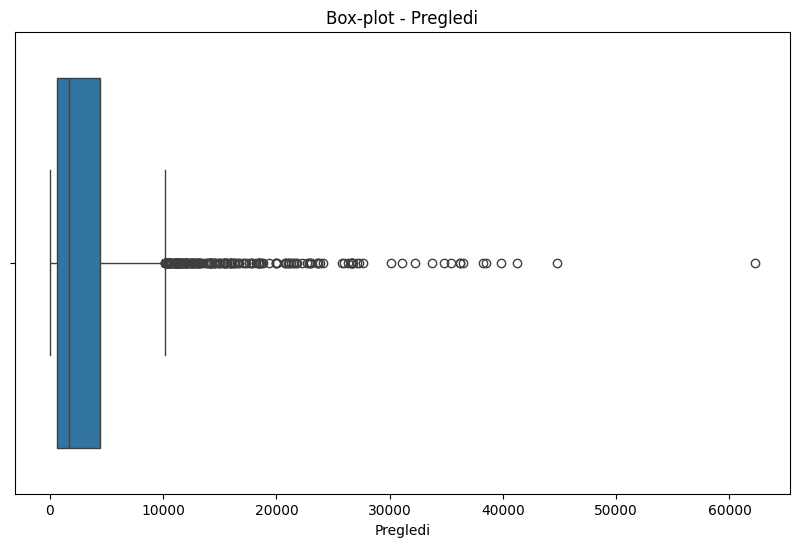

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Pregledi'].dropna())
plt.title('Box-plot - Pregledi')
plt.xlabel('Pregledi')
plt.show()

Kolona "Pregledi", uopšte ne prati normalnu distribuciju, te možemo zaključiti i iz box plota da velika većina postavljenih automobila ima relativno mali broj pregleda, što je i za očekivati.

##2.3. Cijena

In [ ]:
df.loc[:, 'Cijena'] = pd.to_numeric(df['Cijena'], errors='coerce')
data = df.dropna(subset=['Cijena'])

data['Cijena'].describe()

count      1875.0
unique      712.0
top       10500.0
freq         18.0
Name: Cijena, dtype: float64

Zbog značajnih ekstrema, izbacit ćemo 5% najvećih cijena, radi kvalitetnije analize i vizualizacije podataka.

In [ ]:
threshold = data['Cijena'].quantile(0.95)
filtered_df = data[data['Cijena'] <= threshold]

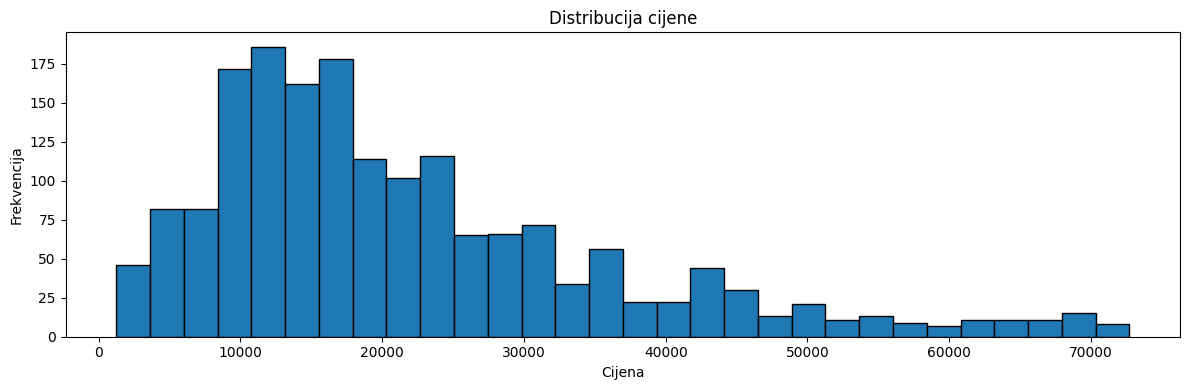

In [ ]:
plt.figure(figsize=(12, 4))

plt.hist(filtered_df['Cijena'], bins=30, edgecolor='k')
plt.title('Distribucija cijene')
plt.xlabel('Cijena')
plt.ylabel('Frekvencija')
plt.tight_layout()
plt.show()

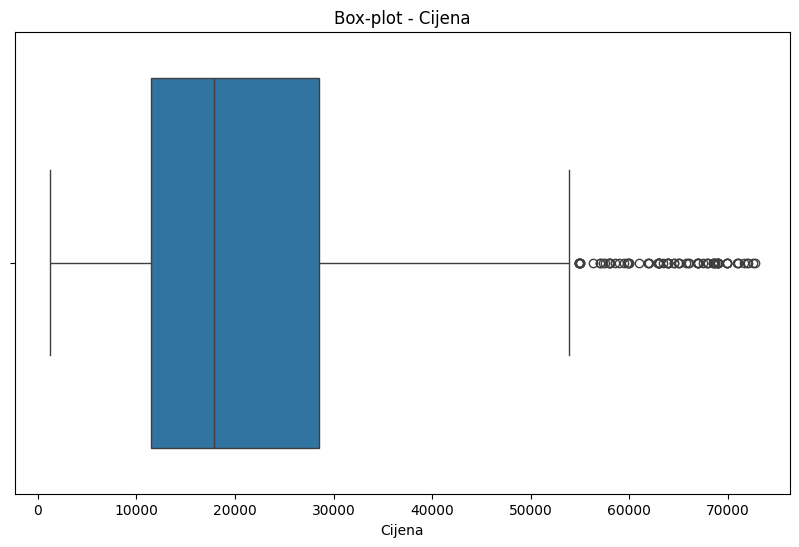

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=filtered_df['Cijena'])
plt.title('Box-plot - Cijena')
plt.xlabel('Cijena')
plt.show()

Vidimo da cijena otprilike prati chi-kvadratnu distribuciju, te da se većina cijena automobila nalazi između 10 i 30 hiljada KM. Medijan je oko 18 hiljada, te vidimo da postoji značajan broj ekstrema, tj. automobila sa cijenom preko 54 hiljade KM, unatoč činjenici da se vršilo već jedno filtriranje.

##2.4. Proizvođači

In [ ]:
unique_manufacturers = df['Proizvodjac'].nunique()
manufacturers_list = df['Proizvodjac'].unique()
print("Broj proizvodjaca:", unique_manufacturers)
print("Lista proizvodjaca:")
for manufacturer in manufacturers_list:
    print("-", manufacturer)


Broj proizvodjaca: 34
Lista proizvodjaca:
- Mercedes-Benz
- Seat
- Volkswagen
- Opel
- Audi
- BMW
- Skoda
- Ford
- Peugeot
- Volvo
- Renault
- Citroen
- Toyota
- Fiat
- Mitsubishi
- Dacia
- Mazda
- Nissan
- Smart
- Hyundai
- Land Rover
- Alfa Romeo
- Porsche
- Jaguar
- MINI
- Suzuki
- Kia
- Ssangyong
- Chevrolet
- Isuzu
- Lancia
- Lada
- Jeep
- Subaru


Unutar dataset-a se nalazi 34 unikatna proizvođača automobila, čiju ćemo raspodjelu po broju objavljenih automobila sada da vidimo.

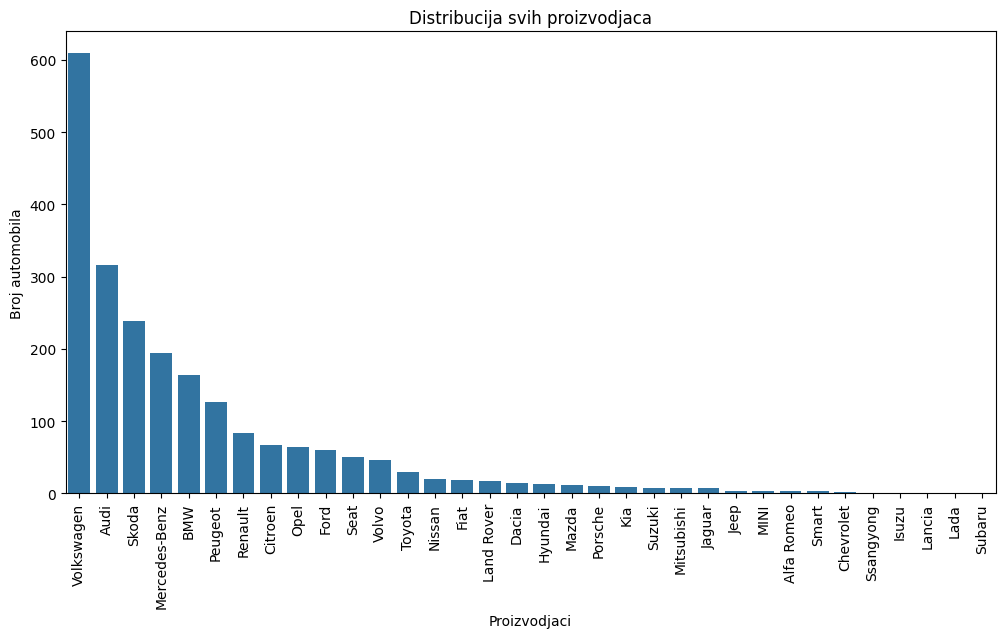

In [ ]:
manufacturer_counts = df['Proizvodjac'].value_counts()

plt.figure(figsize=(12, 6))
sns.countplot(x='Proizvodjac', data=df, order=manufacturer_counts.index)
plt.title('Distribucija svih proizvodjaca')
plt.xlabel('Proizvodjaci')
plt.ylabel('Broj automobila')
plt.xticks(rotation=90)
plt.show()

Najviše automobila koji su postavljeni na OLX su napravljeni od strane proizvođača Volkswagen, sa oko 600 automobila, te ih sa upola manjim brojem automobila prati Audi, pa onda Škoda, Mercedes... Ostali proizvođači imaju znatno manju reprezentaciju u broju postavljenih automobila.

### Koja su vozila najtraženija prema broju pregleda?

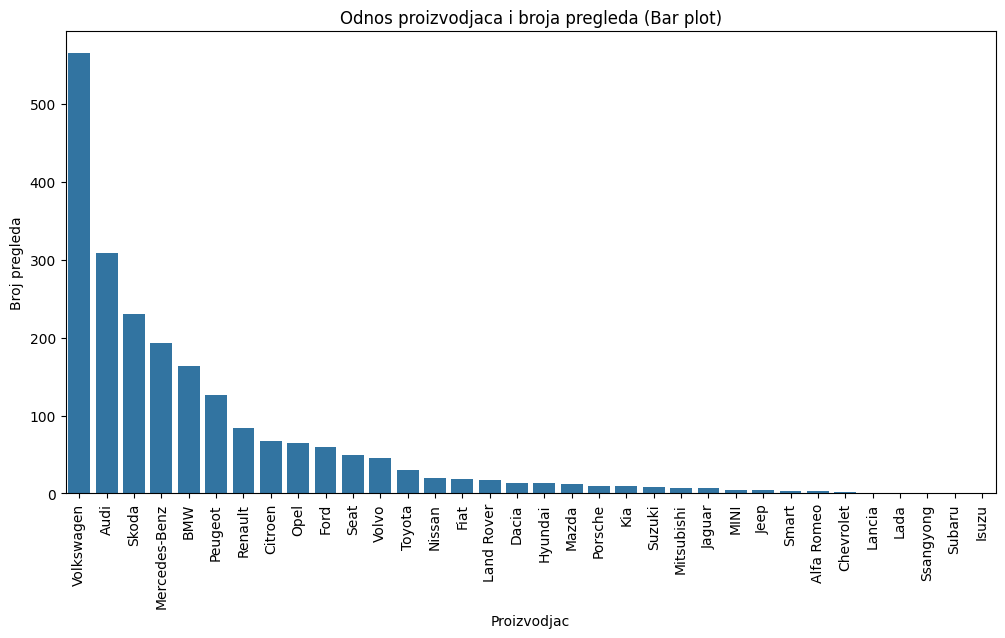

In [ ]:
manufacturer_views = df.groupby('Proizvodjac')['Pregledi'].nunique().reset_index().sort_values(by='Pregledi', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Proizvodjac', y='Pregledi', data=manufacturer_views)
plt.xlabel('Proizvodjac')
plt.ylabel('Broj pregleda')
plt.title('Odnos proizvodjaca i broja pregleda (Bar plot)')
plt.xticks(rotation=90)
plt.show()

Iz ovog dijagrama jasno možemo zaključiti da je Volkswagen najtraženiji prema broju pregleda. Audi i Škoda su odmah iza Volkswagen proizvođača i imaju oko 300 pregleda.
Znatno manje pregleda imaju ostali proizvođači. Zanimljivo je da je raspored i distribucija proizvođača po broju objavljenih automobila i po broju pregleda skoro pa identičan.

##2.5. Modeli

In [ ]:
models_per_manufacturer = df.groupby('Proizvodjac')['Model'].nunique()
print("\nBroj modela po proizvodjacu:")
for manufacturer, count in models_per_manufacturer.items():
    print("-", manufacturer + ":", count)


Broj modela po proizvodjacu:
- Alfa Romeo: 3
- Audi: 17
- BMW: 31
- Chevrolet: 2
- Citroen: 15
- Dacia: 4
- Fiat: 10
- Ford: 11
- Hyundai: 5
- Isuzu: 1
- Jaguar: 4
- Jeep: 3
- Kia: 3
- Lada: 1
- Lancia: 1
- Land Rover: 6
- MINI: 4
- Mazda: 6
- Mercedes-Benz: 63
- Mitsubishi: 4
- Nissan: 9
- Opel: 9
- Peugeot: 16
- Porsche: 3
- Renault: 11
- Seat: 10
- Skoda: 14
- Smart: 1
- Ssangyong: 1
- Subaru: 1
- Suzuki: 6
- Toyota: 9
- Volkswagen: 26
- Volvo: 9


Vidimo da većinom svaki proizvođač ima više različitih modela automobila, od kojih najviše ima Mercedes-Benz sa 63 modela, koga prati BMW sa 31 i Volkswagen sa 26. Zbog ogromnog broja svih modela, posmatrati ćemo modele top 3 proizvođača i po broju pregleda i po broju postavljenih automobila.

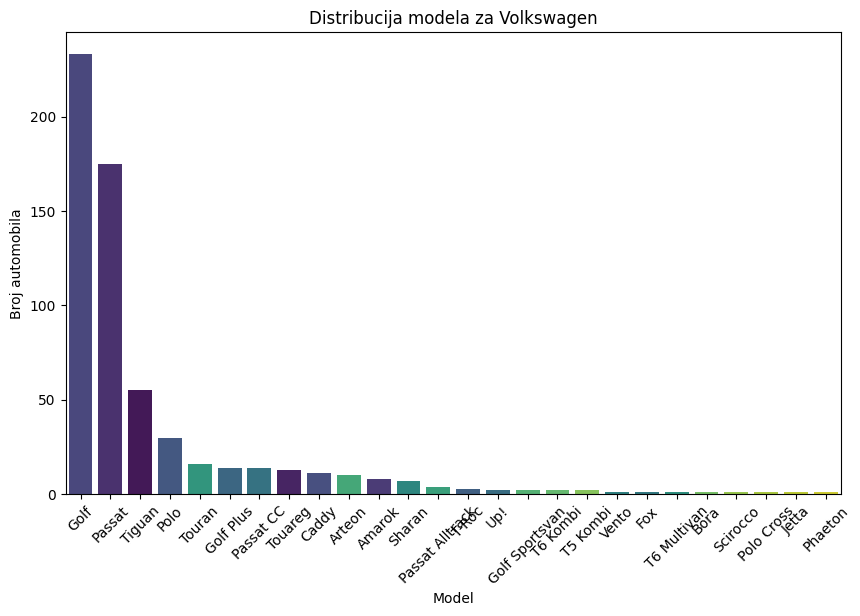

In [ ]:
top_manufacturers = df['Proizvodjac'].value_counts().head(10).index
df_top_manufacturers = df[df['Proizvodjac'].isin(top_manufacturers)]

manufacturer = 'Volkswagen'
plt.figure(figsize=(10, 6))
df_manufacturer = df_top_manufacturers[df_top_manufacturers['Proizvodjac'] == manufacturer]
sns.countplot(x='Model', data=df_manufacturer, hue='Model', palette='viridis', order=df_manufacturer['Model'].value_counts().index, legend=False)
plt.title(f'Distribucija modela za {manufacturer}')
plt.xlabel('Model')
plt.ylabel('Broj automobila')
plt.xticks(rotation=45)
plt.show()

Najpopularniji modeli Volkswagen automobila su Golf i Passat, koji imaju oko 230 i 175 postavljenih automobila respektivno. Sa znatno manjim brojem ih prate modeli Tiguan, Polo i drugi.

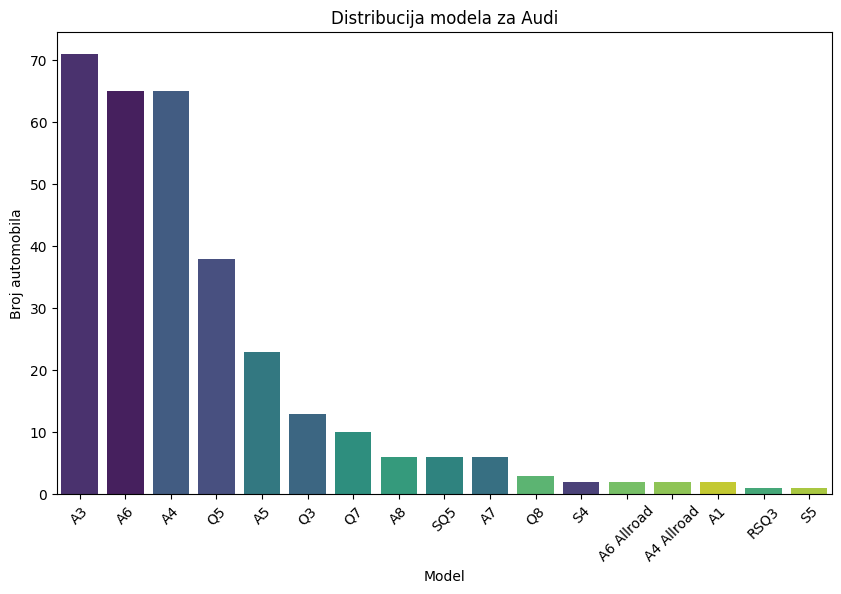

In [ ]:
manufacturer = 'Audi'
plt.figure(figsize=(10, 6))
df_manufacturer = df_top_manufacturers[df_top_manufacturers['Proizvodjac'] == manufacturer]
sns.countplot(x='Model', data=df_manufacturer, hue='Model', palette='viridis', order=df_manufacturer['Model'].value_counts().index, legend=False)
plt.title(f'Distribucija modela za {manufacturer}')
plt.xlabel('Model')
plt.ylabel('Broj automobila')
plt.xticks(rotation=45)
plt.show()

A3, A4 i A6 modeli Audija imaju skoro pa identičan broj postavljnenih automobila (oko 65-70), iza kojih se nalaze modeli Q5 (oko 38), A5 (oko 25) i drugi modeli sa znatno slabijom reprezentacijom.

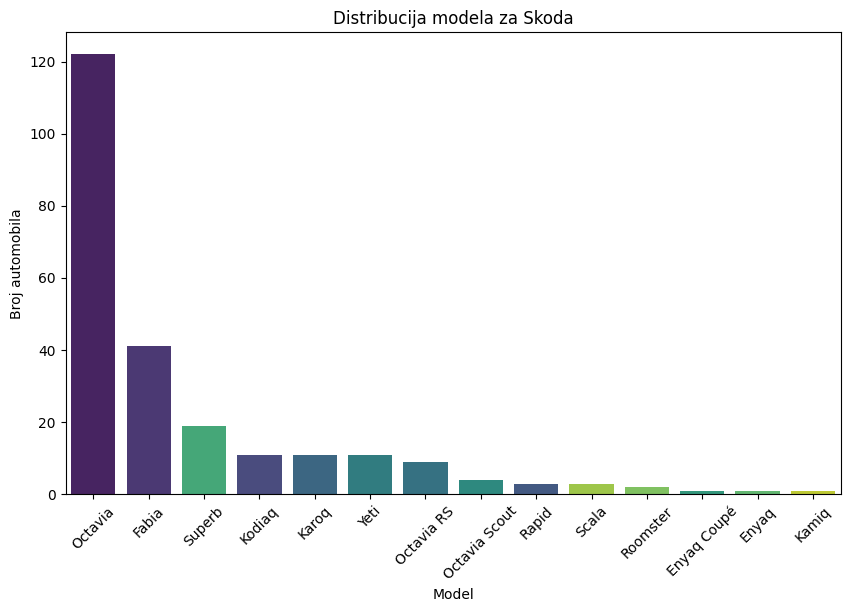

In [ ]:
manufacturer = 'Skoda'
plt.figure(figsize=(10, 6))
df_manufacturer = df_top_manufacturers[df_top_manufacturers['Proizvodjac'] == manufacturer]
sns.countplot(x='Model', data=df_manufacturer, hue='Model', palette='viridis', order=df_manufacturer['Model'].value_counts().index, legend=False)
plt.title(f'Distribucija modela za {manufacturer}')
plt.xlabel('Model')
plt.ylabel('Broj automobila')
plt.xticks(rotation=45)
plt.show()

Octavia je daleko najpopularniji model Škode sa oko 120 postavljenih automobila. Iza nje se sa oko 40 postavljenih auta nalazi Fabia, te sa još upola manjim brojem auta Superb. Zanimljivo je da modeli Kodiaq, Karoq, Yeti i Octavia RS imaju skoro pa isti broj automobila (oko 10).

##2.6. Gorivo

In [ ]:
cars_per_fuel_type = df['Gorivo'].value_counts()
print("\nNumber of cars for each fuel type:")
for fuel_type, count in cars_per_fuel_type.items():
    print("-", fuel_type + ":", count)


Number of cars for each fuel type:
- Dizel: 1933
- Benzin: 239
- Plin: 20
- Hibrid: 12
- Elektro: 4


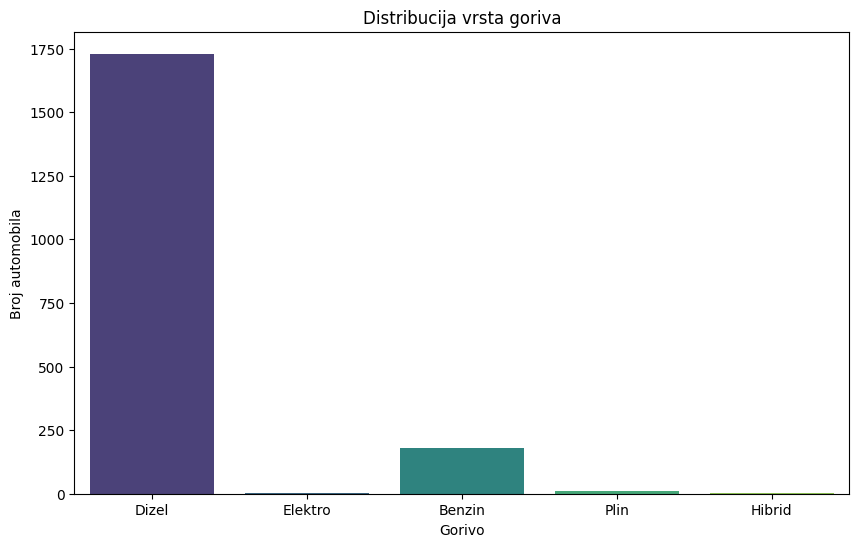

In [ ]:
# Plot the distribution of Gorivo for the filtered data
plt.figure(figsize=(10, 6))
sns.countplot(x='Gorivo', data=df_top_manufacturers, hue='Gorivo', palette='viridis', legend=False)
plt.title('Distribucija vrsta goriva')
plt.xlabel('Gorivo')
plt.ylabel('Broj automobila')
plt.show()

Dizel je daleko najrasprostranjeniji vid goriva u automobilima sa OLX-a, gdje 1933 automobila iz ovog dataset-a koriste dizel. Benzin je drugo najpopularnije gorivo, sa 239 automobila koje ga koriste, dok su Electro, Plin i Hibrid skoro pa zanemarivi i jedva reprezentirani u ovom datesetu. Slaba rasprostranjenost Electro i Hibridnih vozila je i za očekivati, kako je OLX stranica koja se većinski koristi za prodaju polovnih automobila (što smo vidjeli u grafiku iznad), a Electro i Hibridna goriva se većinom koriste u novim autima, te ovi tipovi goriva sami po sebi nisu rasprostranjeni u BiH zbog manjka infrastrukture.

###Distribucija proizvodjaca po vrsti goriva

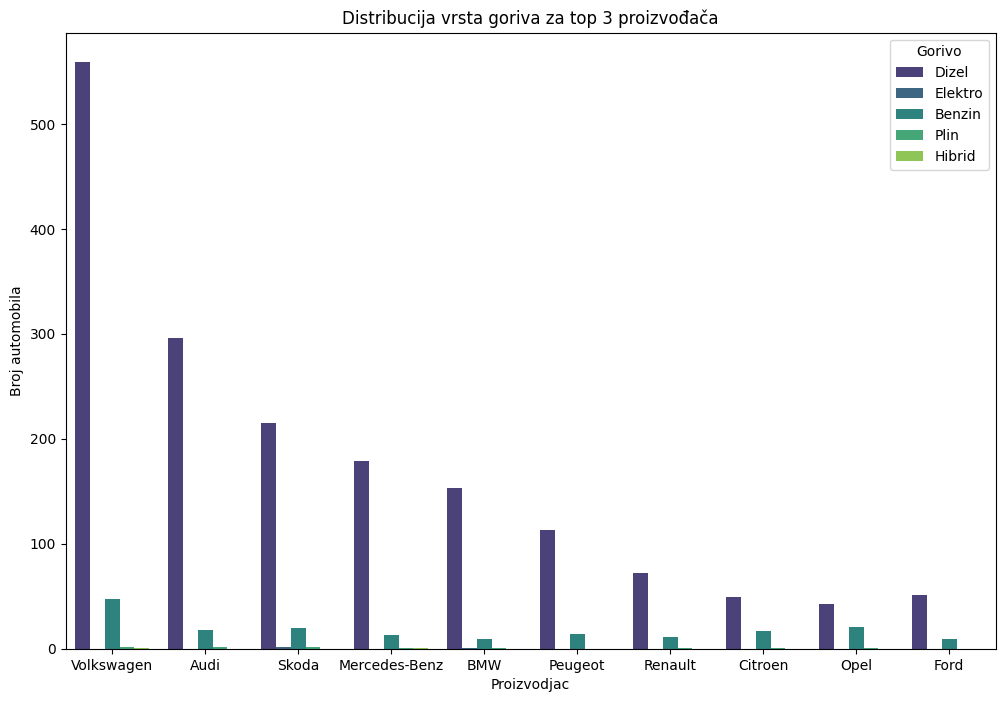

In [ ]:
# Plot the distribution of Manufacturers by Fuel Type
plt.figure(figsize=(12, 8))
sns.countplot(x='Proizvodjac', hue='Gorivo', data=df_top_manufacturers, palette='viridis', order=top_manufacturers)
plt.title('Distribucija vrsta goriva za top 3 proizvođača')
plt.xlabel('Proizvodjac')
plt.ylabel('Broj automobila')
plt.legend(title='Gorivo')
plt.show()

Kod svakog proizvođača, primarno gorivo je dizel, dok je iza njega benzin, kao što nam je i pokazao prethodi grafik. Zanimljivo je da kod svih proizvođača ta razlika veoma velika, sem kod Citroena i Opela, gdje su otprilike 2/3 svih objavljenih automobila ovih proizvođača dizelaši, a 1/3 benzinci.

## 2.7. Godiste

In [ ]:
columns_to_analyze = ['Godiste', 'Transmisija', 'Kilometraza']
data.loc[:, 'Godiste'] = pd.to_numeric(data['Godiste'], errors='coerce')
data.loc[:, 'Kilometraza'] = pd.to_numeric(data['Kilometraza'], errors='coerce')

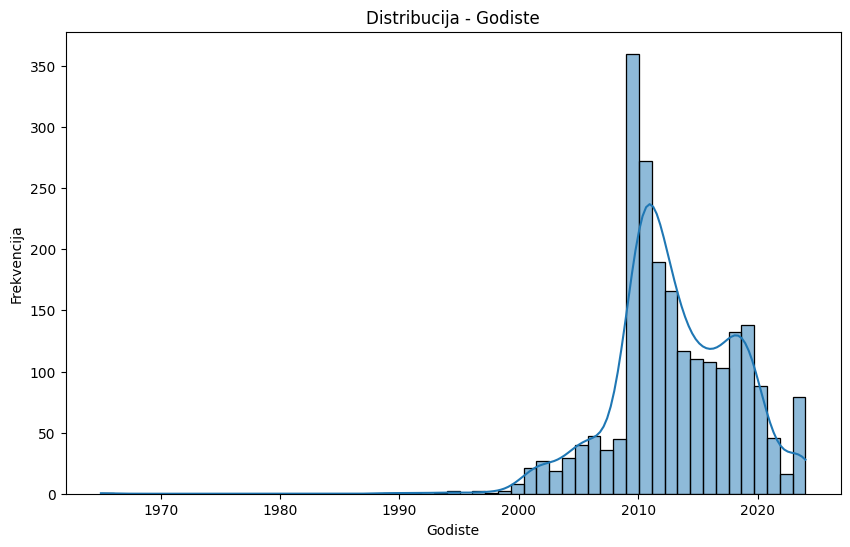

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Godiste'].dropna(), kde=True)
plt.title('Distribucija - Godiste')
plt.xlabel('Godiste')
plt.ylabel('Frekvencija')
plt.show()

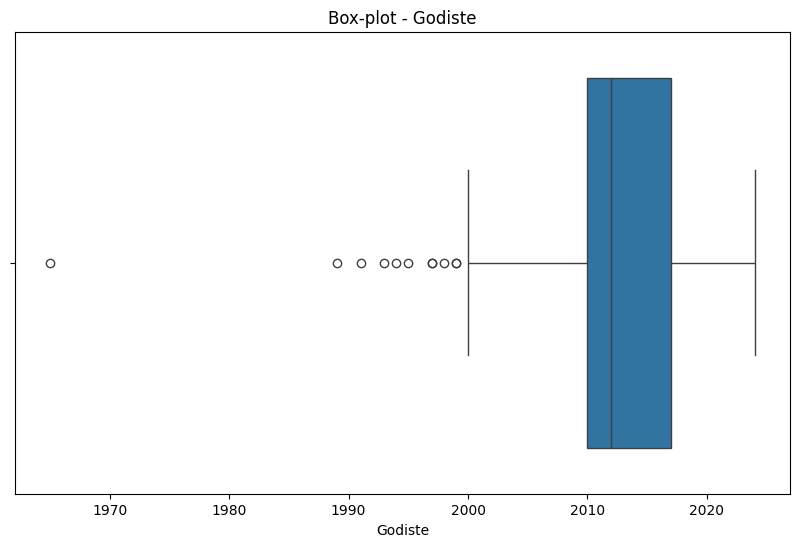

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Godiste'].dropna())
plt.title('Box-plot - Godiste')
plt.xlabel('Godiste')
plt.show()

Godište automobila postavljenih na OLX se većinski kreće od 2000. pa do 2024., ali većina automobila iz dataset-a proizvedeni između 2010. i 2015.

## 2.8. Transmisija

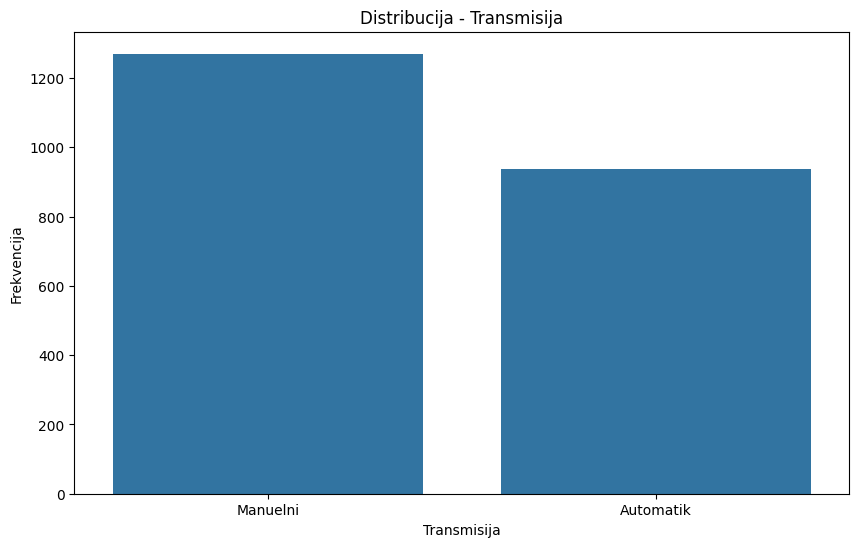

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x=df['Transmisija'])
plt.title('Distribucija - Transmisija')
plt.xlabel('Transmisija')
plt.ylabel('Frekvencija')
plt.show()

Automobili sa manuelnom transmisijom su najrasporstranjeniji, ali i automatici drže značajan dio tržišta.

###Postoji li veza izmjeđu godišta automobila i transmisije koju on ima?

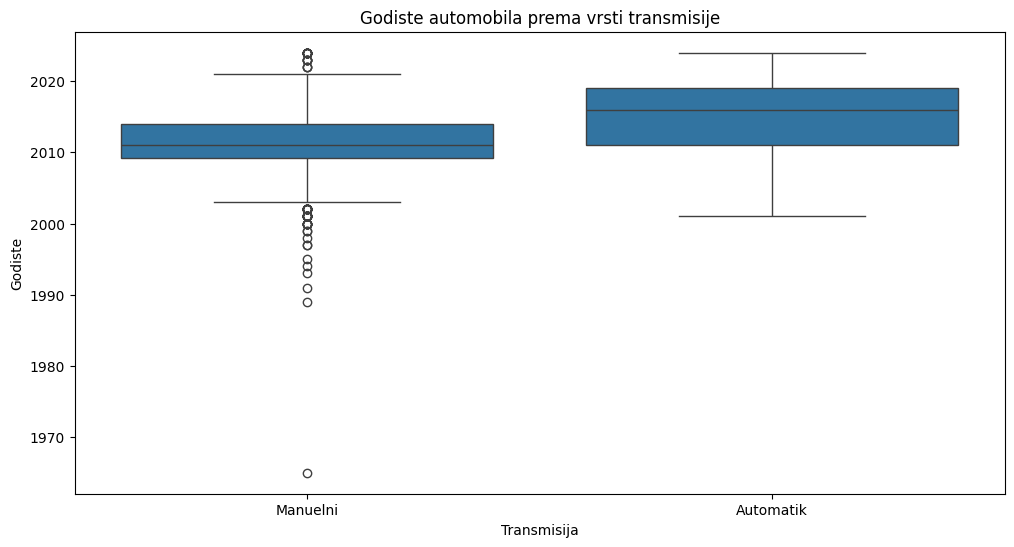

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Transmisija', y='Godiste', data=df)
plt.title('Godiste automobila prema vrsti transmisije')
plt.xlabel('Transmisija')
plt.ylabel('Godiste')
plt.show()

**Zaključak**
Automobili sa automatskom transmisijom često su proizvedeni u nešto kasnijim godinama u poređenju sa automobilima sa manuelnom transmisijom.
Ovaj trend može ukazivati na evoluciju tehnologije transmisije tokom vremena, gdje su automobili sa automatskom transmisijom postali popularniji u kasnijim godinama.









###Koliki je procenat novih vozila sa automatskom transmisijom među vozilima određenog proizvođača (npr. Audi)?

In [ ]:
import pandas as pd
from statsmodels.stats.proportion import proportion_confint

data = df

filter_condition = (data['Proizvodjac'] == 'Audi') & (data['Stanje'] == 'Novo') & (data['Transmisija'] == 'Automatik')
filtered_data = data[filter_condition]

broj_ponavljanja = len(filtered_data)
print("Broj novih vozila proizvođača Audi sa automatskom transmisijom je:", broj_ponavljanja)

ukupan_broj_Audi = len(data[data['Proizvodjac'] == 'Audi'])
print("Ukupan broj vozila proizvođača Audi je:", ukupan_broj_Audi)

ci_lower, ci_upper = proportion_confint(count=broj_ponavljanja, nobs=ukupan_broj_Audi, alpha=0.05)

print("Proporcija novih vozila proizvođača Audi sa automatskom transmisijom: {:.2f}".format(broj_ponavljanja / ukupan_broj_Audi))
print("95% interval pouzdanosti proporcije: ({:.2f}, {:.2f})".format(ci_lower, ci_upper))


Broj novih vozila proizvođača Audi sa automatskom transmisijom je: 5
Ukupan broj vozila proizvođača Audi je: 316
Proporcija novih vozila proizvođača Audi sa automatskom transmisijom: 0.02
95% interval pouzdanosti proporcije: (0.00, 0.03)


##2.9. Kilometraža

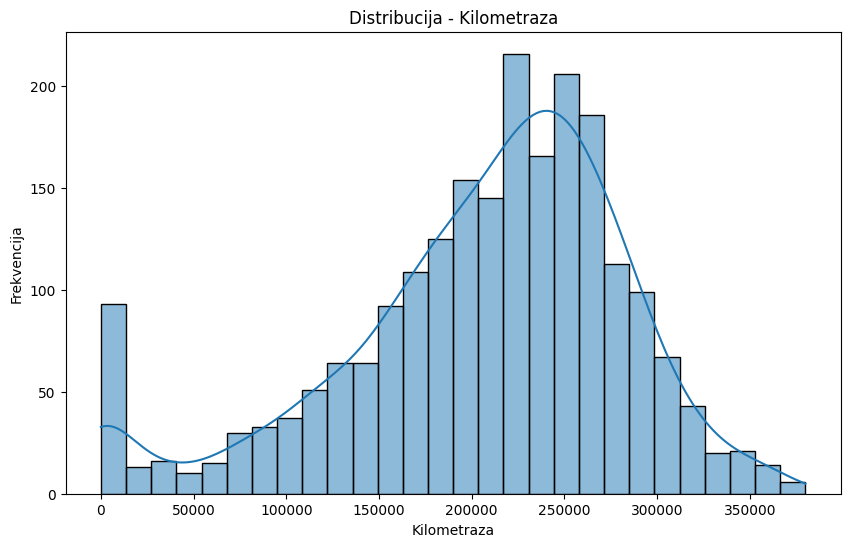

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Kilometraza'].dropna(), kde=True)
plt.title('Distribucija - Kilometraza')
plt.xlabel('Kilometraza')
plt.ylabel('Frekvencija')
plt.show()

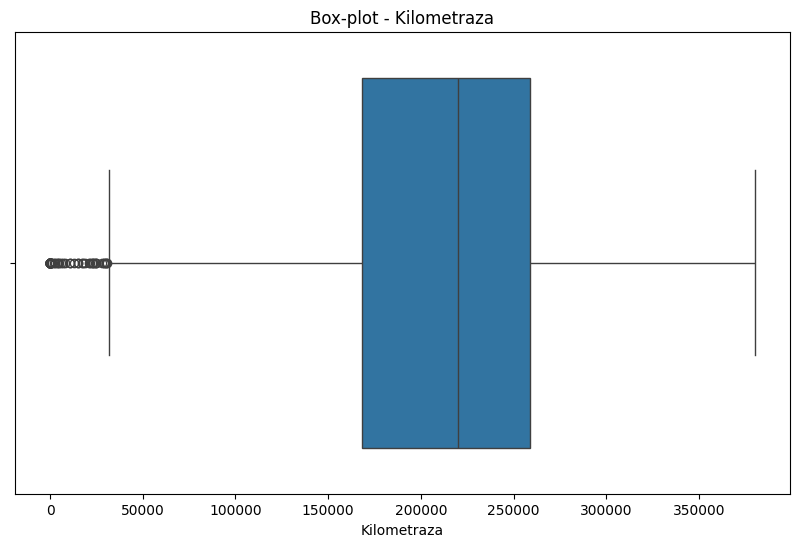

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Kilometraza'].dropna())
plt.title('Box-plot - Kilometraza')
plt.xlabel('Kilometraza')
plt.show()

Kako unatoč tome da su automobili na OLX-u većinski korištena vozila, postoji veliki broj outliera sa kilometražom 0, dok su ostala vozila većinom prešla između 160 i 260 hiljada kilometara.

###Kako se broj predjenih kilometara automobila odražava na njegovu cijenu?

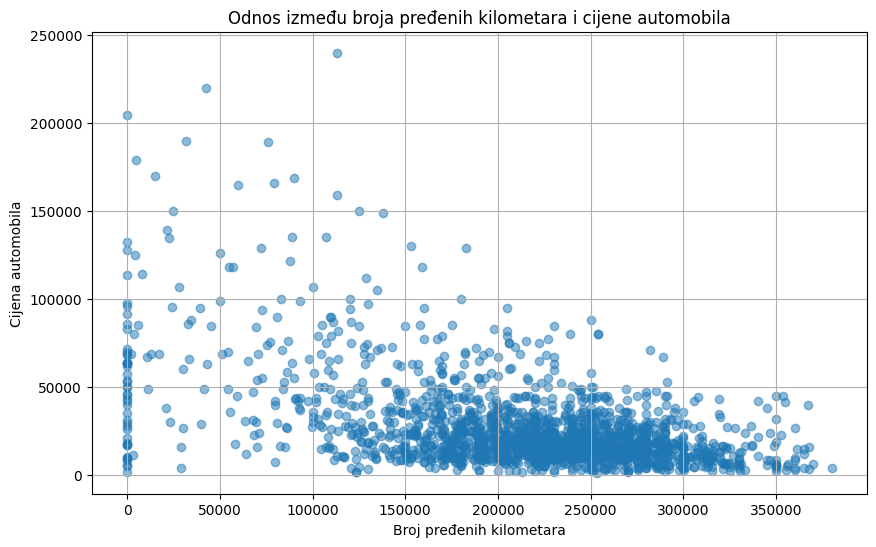

In [ ]:
data = df

plt.figure(figsize=(10, 6))
plt.scatter(data['Kilometraza'], data['Cijena'], alpha=0.5)
plt.title('Odnos između broja pređenih kilometara i cijene automobila')
plt.xlabel('Broj pređenih kilometara')
plt.ylabel('Cijena automobila')
plt.grid(True)
plt.show()

**Zaključak:** Postoji općeniti trend da kako broj pređenih kilometara raste, cijena automobila obično opada. To sugerira da postoji inverzna veza između kilometraže automobila i njegove cijene; veća kilometraža često korelira s nižim cijenama. Ovaj trend vizualno potvrđuje uobičajenu pretpostavku da automobili gube na vrijednosti kako akumuliraju više kilometara.

### Kako se cijena vozila mijenja u odnosu na godinu proizvodnje i kilometražu vozila?

<ipython-input-26-6adafba7581c>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cijena'] = pd.to_numeric(df['Cijena'], errors='coerce')


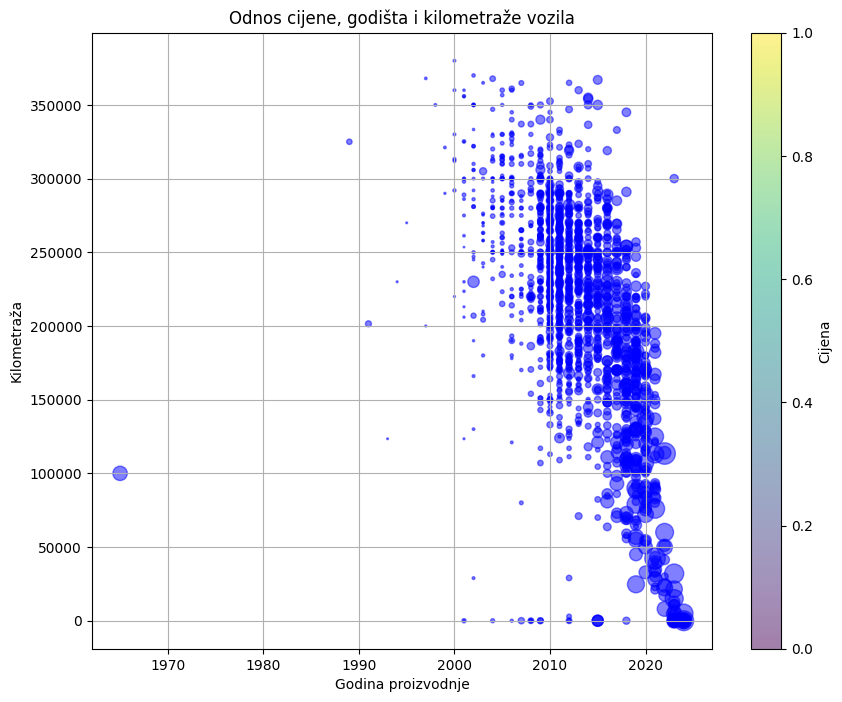

In [ ]:
df['Cijena'] = pd.to_numeric(df['Cijena'], errors='coerce')

df_cleaned = df.dropna(subset=['Godiste', 'Kilometraza', 'Cijena'])

plt.figure(figsize=(10, 8))
plt.scatter(df_cleaned['Godiste'], df_cleaned['Kilometraza'], s=df_cleaned['Cijena']/1000, alpha=0.5, c='blue')
plt.xlabel('Godina proizvodnje')
plt.ylabel('Kilometraža')
plt.title('Odnos cijene, godišta i kilometraže vozila')
plt.colorbar(label='Cijena')
plt.grid(True)
plt.show()

**Zaključak:** Kako se krećemo s lijeva na desno po x-osi (koja predstavlja starije godine), nailazimo na vozila s različitim nivoima kilometraže.
Stariji automobili obično imaju veću kilometražu zbog dužeg vremena na putu.
Intenzitet boje svake tačke odražava cijenu. Svjetlije nijanse odgovaraju nižim cijenama, dok tamnije nijanse označavaju više cijene.

Zanimljivo je da postoji uočljiv obrazac, a to je da vozila s višim cijenama obično imaju manju kilometražu, bez obzira na godinu proizvodnje.
Ovo sugeriše da su kupci spremni da plate premiju za vozila sa malom kilometražom, čak i ako su starija.

##2.10. Kubikaža


In [ ]:
data = df
columns_to_analyze = ['Kubikaza', 'Snaga motora (KW)', 'Broj vrata']
data.loc[:, 'Kubikaza'] = pd.to_numeric(data['Kubikaza'], errors='coerce')
data.loc[:, 'Snaga motora (KW)'] = pd.to_numeric(data['Snaga motora (KW)'], errors='coerce')

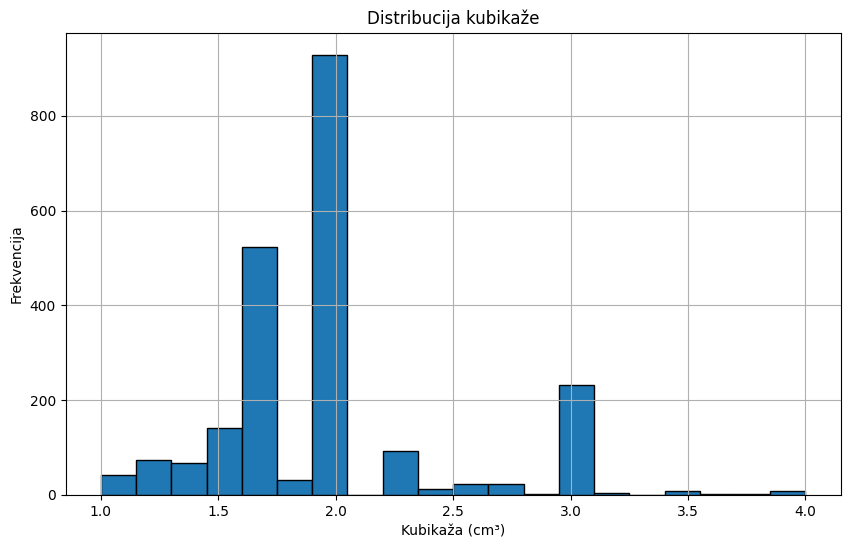

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(data['Kubikaza'], bins=20, edgecolor='black')
plt.title('Distribucija kubikaže')
plt.xlabel('Kubikaža (cm³)')
plt.ylabel('Frekvencija')
plt.grid(True)
plt.show()

Najveći broj automobila ima 2.0 kubika, ili manje, mada postoji i nezanemariv broj automobila sa 3.0 kubika.

###Kako se distribuira kubikaža u vozilima različitog godišta?


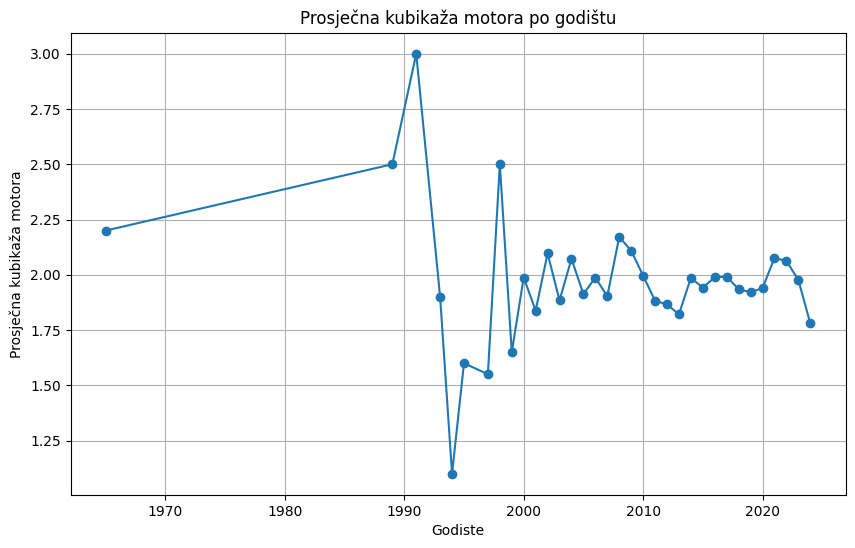

In [ ]:
data = df

prosjecna_kubikaza_po_godistu = data.groupby('Godiste')['Kubikaza'].mean()

plt.figure(figsize=(10, 6))
plt.plot(prosjecna_kubikaza_po_godistu.index, prosjecna_kubikaza_po_godistu.values, marker='o', linestyle='-')
plt.title('Prosječna kubikaža motora po godištu')
plt.xlabel('Godiste')
plt.ylabel('Prosječna kubikaža motora')
plt.grid(True)
plt.show()


Sa grafa iznad možemo zaključiti da kubikaža motora automobila proizvedenih u razdoblju izmedju ranih 1970-ih i kasnih 1980-ih godina doživljava postepeni porast u rasponu od 2.25 do 2.50 litara, da bi tokom ranih 1990-ih naglo porasla i dosegla skoro 3,00 litre. Nakon tog inicijalnog porasta, slijede značajne fluktuacije. Prosječna kubikaža varira s vrhovima i padovima sve do stabilizacije nakon 2000. godine. U tom razdoblju, prosječna kubikaža iznosi otprilike 1,75 do 2,00 litre. Na temelju ovog grafa, ne možemo zaključiti da novija vozila imaju veće ili manje kubikaže u prosjeku. Umjesto toga, primjećujemo promjene tokom godina, ali bez konstantnog trenda.

##2.11. Snaga motora (kW)

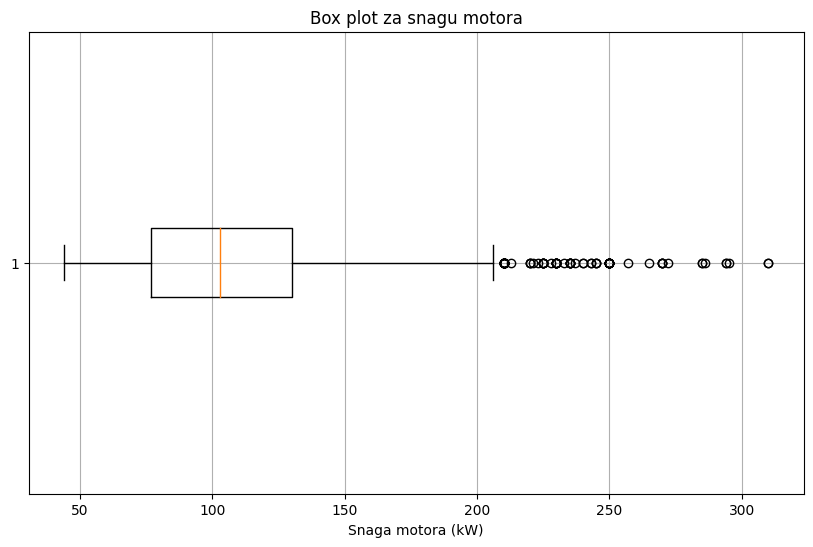

In [ ]:
plt.figure(figsize=(10, 6))
plt.boxplot(data['Snaga motora (KW)'].dropna(), vert=False)
plt.title('Box plot za snagu motora')
plt.xlabel('Snaga motora (kW)')
plt.grid(True)
plt.show()

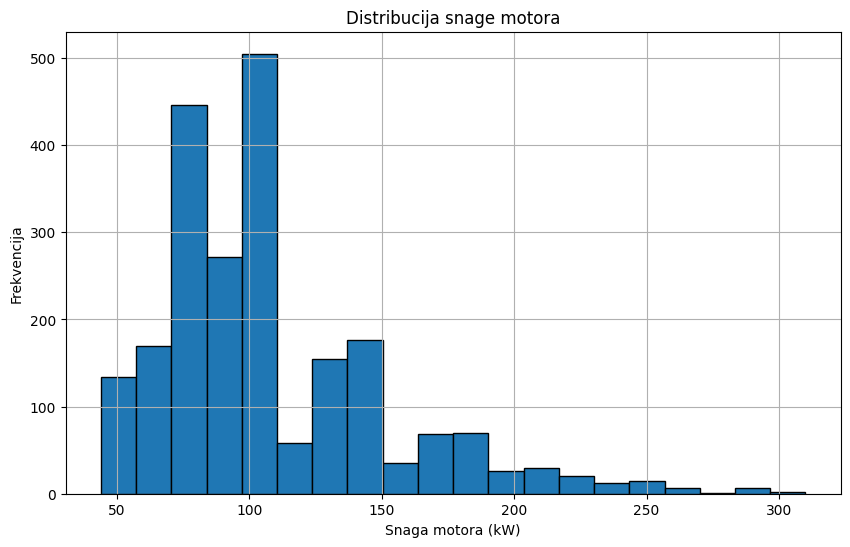

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(data['Snaga motora (KW)'], bins=20, edgecolor='black')
plt.title('Distribucija snage motora')
plt.xlabel('Snaga motora (kW)')
plt.ylabel('Frekvencija')
plt.grid(True)
plt.show()

Snaga motora također otprilike prati chi-kvadratnu distrbuciju, gdje većina automobila ima motor sa snagom između 80 i 170 kW

##2.12. Broj vrata

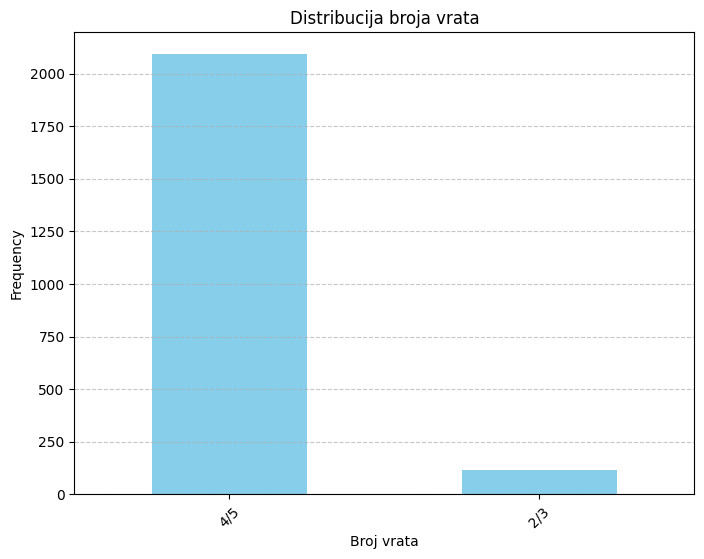

In [ ]:
value_counts = data['Broj vrata'].value_counts()

# Plotting the bar chart
plt.figure(figsize=(8, 6))
value_counts.plot(kind='bar', color='skyblue')
plt.title('Distribucija broja vrata')
plt.xlabel('Broj vrata')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# **3. Chi-square test nezavisnosti kategorijskih varijabli**

**3.1** Koristeći chi-square test za ispitivanje nezavisnosti kategorijskih varijabli prvo ćemo ispitati kakva je zavisnost između goriva automobila i transmisije. Prvobitno važno je postaviti nultu (H0) i alternativnu hipotezu (H1) koje u ovom slučaju izgledaju ovako:

**Hipoteza 1:** Vrsta goriva i transmisija

H0 - Ne postoji veza između vrste goriva koje koriste vozila i njihovog tipa prenosa.

H1 - Postoji veza između vrste goriva koje koriste vozila i njihovog tipa prenosa.

Potrebno je odrediti nivo značajnosti na osnovu kojeg ćemo razmatrati prihvatanje/odbacivanje nulte-hipoteze.

In [ ]:
from scipy.stats import chi2_contingency, chi2
data = df
R = data['Gorivo'].nunique()
C = data['Transmisija'].nunique()

v = (R - 1) * (C - 1)

alpha = 0.05

kriticnavr = chi2.ppf(1 - alpha, v)

print("Nivo značajnosti:", alpha)
print("Kritična vrijednost:", kriticnavr)

# Izračunavanje kontingencijske tablice
contingency_table = pd.crosstab(data['Proizvodjac'], data['Gorivo'])

# Chi-square test
chi2, p_value, _, _ = chi2_contingency(contingency_table)

print("Rezultati testa:")
print("Chi-square statistika:", chi2)
print("p-vrijednost:", p_value)

alpha = 0.05  # Nivo značajnosti
if p_value < alpha:
    print("Odbacujemo nultu hipotezu.")
    print("Postoji značajna veza između vrste goriva i transmisije.")
else:
    print("Prihvaćamo nultu hipotezu.")
    print("Nema dovoljno dokaza za zaključiti da postoji veza između vrste goriva i transmisije.")

Nivo značajnosti: 0.05
Kritična vrijednost: 9.487729036781154
Rezultati testa:
Chi-square statistika: 1047.728505479098
p-vrijednost: 2.392964969964753e-142
Odbacujemo nultu hipotezu.
Postoji značajna veza između vrste goriva i transmisije.


**Zaključak:** Analiza nam pokazuje da je chi-square statistika veća od kritične vrijednosti i da je p-vrijednost manja od nivoa značajnosti od 0.05, zbog čega odbacujemo nultu hipotezu (H0).

Na osnovu rezultata chi-square testa nezavisnosti, možemo zaključiti da postoji statistički značajna veza između vrste goriva koje koriste vozila i njihovog tipa prenosa. Drugim riječima, distribucija vrste goriva nije nezavisna od tipa prenosa. Ovo sugeriše da određeni tipovi prenosa imaju tendenciju da budu povezani sa određenim vrstama goriva.

**3.2.** Koristeći chi-square test ispitat cemo da li neki proizvođači automobila imaju tendenciju da proizvode vozila koja koriste specifične vrste goriva.

**Hipoteza 2:** Proizvođač i vrsta goriva

H0 (Nulta hipoteza): Ne postoji veza između proizvođača automobila i vrste goriva koje koristi.

H1 (Alternativna hipoteza): Postoji veza između proizvođača automobila i vrste goriva koje koristi.

In [ ]:
from scipy.stats import chi2_contingency, chi2
data = df

R = data['Proizvodjac'].nunique()
C = data['Gorivo'].nunique()
v = (R - 1) * (C - 1)
alpha = 0.05
kriticnavr = chi2.ppf(1 - alpha, v)

print("Nivo značajnosti:", alpha)
print("Kritična vrijednost:", kriticnavr)

# Izračunavanje kontingencijske tablice
contingency_table = pd.crosstab(data['Proizvodjac'], data['Gorivo'])
# Chi-square test
chi2, p_value, _, _ = chi2_contingency(contingency_table)

print("\nRezultati testa:")
print("Chi-square statistika:", chi2)
print("p-vrijednost:", p_value)

alpha = 0.05  # Nivo značajnosti
if p_value < alpha:
    print("Odbacujemo nultu hipotezu.")
    print("Postoji značajna veza između proizvodjaca automobila i vrste goriva.")
else:
    print("Prihvaćamo nultu hipotezu.")
    print("Nema dovoljno dokaza za zaključiti da postoji veza između proizvodjaca automobila i vrste goriva.")

Nivo značajnosti: 0.05
Kritična vrijednost: 159.8135468509978

Rezultati testa:
Chi-square statistika: 1047.728505479098
p-vrijednost: 2.392964969964753e-142
Odbacujemo nultu hipotezu.
Postoji značajna veza između proizvodjaca automobila i vrste goriva.


**Zaključak:** S obzirom na unaprijed određeni nivo značajnosti od 0.05, p-vrijednost je manja od nivoa značajnosti. Stoga možemo zaključiti da postoji izuzetno snažna statistička veza između proizvođača automobila i vrste goriva koje koriste. Ovi rezultati sugerišu da određeni proizvođači automobila imaju tendenciju da proizvode vozila koja koriste specifične vrste goriva.

Ovi podaci mogu biti korisni za dalje istraživanje tržišta automobila, pomoći u planiranju proizvodnje i marketing strategija, kao i u donošenju odluka koje se odnose na razvoj novih modela i tehnologija.

**3.3** Koristeći chi-square test ispitat cemo da li neki proizvođači automobila imaju tendenciju da proizvode vozila koja koriste specifične vrste transmije.

**Hipoteza 3:** Transmisija i Proizvodjac

H0 (Nulta hipoteza): Ne postoji veza između vrste prenosa automobila i proizvođača.

H1 (Alternativna hipoteza): Postoji veza između vrste prenosa automobila i proizvođača.

In [ ]:
from scipy.stats import chi2, chi2_contingency
data = df
R = data['Proizvodjac'].nunique()
C = data['Transmisija'].nunique()
v = (R - 1) * (C - 1)
alpha = 0.05
kriticnavr = chi2.ppf(1 - alpha, v)

print("Nivo značajnosti:", alpha)
print("Kritična vrijednost:", kriticnavr)

# Izračunavanje kontingencijske tablice
contingency_table = pd.crosstab(data['Proizvodjac'], data['Transmisija'])

# Chi-square test
chi2, p_value, _, _ = chi2_contingency(contingency_table)

print("\nRezultati testa:")
print("Chi-square statistika:", chi2)
print("p-vrijednost:", p_value)

alpha = 0.05  # Nivo značajnosti
if p_value < alpha:
    print("Odbacujemo nultu hipotezu.")
    print("Postoji značajna veza između proizvodjaca automobila i transmisije.")
else:
    print("Prihvaćamo nultu hipotezu.")
    print("Nema dovoljno dokaza za zaključiti da postoji veza između proizvodjaca automobila i transmisije.")

Nivo značajnosti: 0.05
Kritična vrijednost: 47.39988391908093

Rezultati testa:
Chi-square statistika: 416.3715439974513
p-vrijednost: 6.923315273449745e-68
Odbacujemo nultu hipotezu.
Postoji značajna veza između proizvodjaca automobila i transmisije.


**Zaključak:** Na temelju analize rezultata testa s nivoom značajnosti od 0.05, zaključujemo da postoji značajna veza između proizvođača automobila i tipa transmisije. Chi-square statistika od 414.64 značajno premašuje kritičnu vrijednost od 47.40, dok je p-vrijednost znatno manja od postavljenog nivoa značajnosti, što ukazuje na odbacivanje nulte hipoteze. Stoga, na osnovu dobivenih rezultata, možemo zaključiti da postoji statistički značajna povezanost između proizvođača automobila i tipa transmisije.

#**4. Estimacija intervala pouzdanosti proporcije za kategorijske varijable**


Estimacija intervala pouzdanosti proporcije za kategorijske varijable  se koristi za procjenu intervala u kojem će, sa određenim nivoom pouzdanosti, ležati prava vrijednost populacione proporcije na osnovu uzorka iz populacije. Ovo je posebno korisno kada analiziramo kategorijske varijable, koje predstavljaju podatke u obliku kategorija ili grupa (npr. u našem slučaju to su vrsta goriva, tip transmisije, proizvođač automobila, model automobila, stanje...).

## Koraci u Procesu Estimacije Intervala Pouzdanosti Proporcije:

**1. Identifikacija Kategorijske Varijable i Vrijednosti za Analizu:**

-Odaberemo kategorijsku varijablu (npr. tip goriva).

-Odredimo specifičnu vrijednost unutar te varijable za koju želimo izračunati proporciju (npr. benzin).

 **2. Izračunavanje Proporcije u Uzorku:**

-Brojimo koliko puta se odabrana vrijednost pojavljuje u uzorku (npr. broj vozila na benzin).

-Izračunamo proporciju te vrijednosti u odnosu na ukupan broj posmatranja (npr. broj vozila na benzin podijeljen sa ukupnim brojem vozila).

**3. Izračunavanje Intervala Pouzdanosti:**

-Koristimo statističke metode (npr. binomna distribucija, normalna aproksimacija) za izračunavanje donje i gornje granice intervala pouzdanosti za procjenjenu proporciju.

Nivo pouzdanosti (npr. 95%) određuje kolika je vjerovatnoća da prava proporcija leži unutar tog intervala.





## 4.1 Estimacija intervala pouzdanosti proporcije koja nam govori koliko je zastupljeno automobila sa automatskom transmisijom

Uzimat ćemo 95%-tni interval pouzdanosti, odnosno α=0,05

In [ ]:
import pandas as pd
from statsmodels.stats.proportion import proportion_confint

value = 'Automatik'
data = df

# Broj automobila sa automatskom transmisijom
broj_ponavljanja = data['Transmisija'].value_counts()[value]
print("Broj ponavljanja vrijednosti", value, "je:", broj_ponavljanja)

# Ukupan broj automobila
broj_vrijednosti = len(data['Transmisija'])
print("Ukupan broj vrijednosti u varijabli", 'Transmisija', "je:", broj_vrijednosti)

# Izračunavanje intervala pouzdanosti za proporciju
ci_lower, ci_upper = proportion_confint(count=broj_ponavljanja, nobs=broj_vrijednosti, alpha=0.05)

print("Proporcija automobila sa automatskom transmisijom: {:.2f}".format(broj_ponavljanja / broj_vrijednosti))
print("95% interval pouzdanosti proporcije: ({:.2f}, {:.2f})".format(ci_lower, ci_upper))

Broj ponavljanja vrijednosti Automatik je: 938
Ukupan broj vrijednosti u varijabli Transmisija je: 2208
Proporcija automobila sa automatskom transmisijom: 0.42
95% interval pouzdanosti proporcije: (0.40, 0.45)


## 4.2 Estimacija intervala pouzdanosti proporcije vozila proizvođača Toyota

In [ ]:
import pandas as pd
from statsmodels.stats.proportion import proportion_confint

value = 'Toyota'
data = df

# Broj vozila proizvođača Toyota
broj_ponavljanja = data['Proizvodjac'].value_counts()[value]
print("Broj ponavljanja vrijednosti", value, "je:", broj_ponavljanja)

# Ukupan broj vozila
broj_vrijednosti = len(data['Proizvodjac'])
print("Ukupan broj vrijednosti u varijabli", 'Proizvođač', "je:", broj_vrijednosti)

# Izračunavanje intervala pouzdanosti za proporciju
ci_lower, ci_upper = proportion_confint(count=broj_ponavljanja, nobs=broj_vrijednosti, alpha=0.05)

print("Proporcija vozila proizvođača Toyota: {:.2f}".format(broj_ponavljanja / broj_vrijednosti))
print("95% interval pouzdanosti proporcije: ({:.2f}, {:.2f})".format(ci_lower, ci_upper))


Broj ponavljanja vrijednosti Toyota je: 30
Ukupan broj vrijednosti u varijabli Proizvođač je: 2208
Proporcija vozila proizvođača Toyota: 0.01
95% interval pouzdanosti proporcije: (0.01, 0.02)


## 4.3 Estimacija intervala pouzdanosti proporcije automobila koji koriste e-gorivo

In [ ]:
import pandas as pd
from statsmodels.stats.proportion import proportion_confint

value = 'Elektro'
data = df

# Broj električnih vozila
broj_ponavljanja = data['Gorivo'].value_counts()[value]
print("Broj ponavljanja vrijednosti", value, "je:", broj_ponavljanja)

# Ukupan broj vozila
broj_vrijednosti = len(data['Gorivo'])
print("Ukupan broj vrijednosti u varijabli", 'Gorivo', "je:", broj_vrijednosti)

# Izračunavanje intervala pouzdanosti za proporciju
ci_lower, ci_upper = proportion_confint(count=broj_ponavljanja, nobs=broj_vrijednosti, alpha=0.05)

print("Proporcija električnih vozila: {:.2f}".format(broj_ponavljanja / broj_vrijednosti))
print("95% interval pouzdanosti proporcije: ({:.2f}, {:.2f})".format(ci_lower, ci_upper))



Broj ponavljanja vrijednosti Elektro je: 4
Ukupan broj vrijednosti u varijabli Gorivo je: 2208
Proporcija električnih vozila: 0.00
95% interval pouzdanosti proporcije: (0.00, 0.00)


## 4.4 Estimacija intervala pouzdanosti proporcije koja govori koliko je polovnih vozila prisutno u datasetu automobila

In [ ]:
import pandas as pd
from statsmodels.stats.proportion import proportion_confint

value = 'Koristeno'
data = df

# Broj polovnih vozila
broj_ponavljanja = data['Stanje'].value_counts()[value]
print("Broj ponavljanja vrijednosti", value, "je:", broj_ponavljanja)

# Ukupan broj vozila
broj_vrijednosti = len(data['Stanje'])
print("Ukupan broj vrijednosti u varijabli", 'Stanje', "je:", broj_vrijednosti)

# Izračunavanje intervala pouzdanosti za proporciju
ci_lower, ci_upper = proportion_confint(count=broj_ponavljanja, nobs=broj_vrijednosti, alpha=0.05)

print("Proporcija polovnih vozila: {:.2f}".format(broj_ponavljanja / broj_vrijednosti))
print("95% interval pouzdanosti proporcije: ({:.2f}, {:.2f})".format(ci_lower, ci_upper))


Broj ponavljanja vrijednosti Koristeno je: 2148
Ukupan broj vrijednosti u varijabli Stanje je: 2208
Proporcija polovnih vozila: 0.97
95% interval pouzdanosti proporcije: (0.97, 0.98)


# **5. Normalna distribucija numeričkih varijabli**

Analiza za kolonu: Pregledi
Kolmogorov-Smirnov test: statistika=0.248389608236254, p-vrijednost=1.721596514621429e-120
Shapiro-Wilk test: statistika=0.6367663145065308, p-vrijednost=0.0


<ipython-input-131-fa848edaad5d>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_numeric(df[col], errors='coerce')


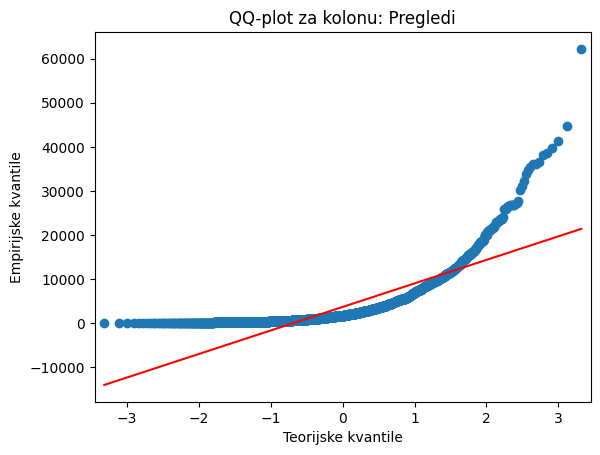


--------------------------------------------------

Analiza za kolonu: Cijena
Kolmogorov-Smirnov test: statistika=0.1825732604155902, p-vrijednost=3.618090781811487e-55
Shapiro-Wilk test: statistika=0.7068054676055908, p-vrijednost=0.0


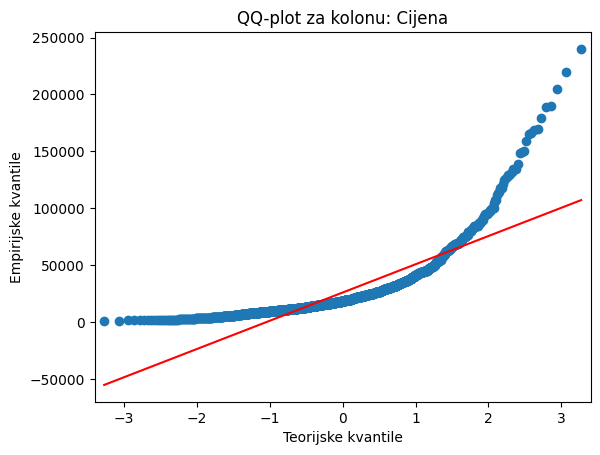


--------------------------------------------------

Analiza za kolonu: Godiste
Kolmogorov-Smirnov test: statistika=0.08873797879421119, p-vrijednost=1.4071283009556087e-15
Shapiro-Wilk test: statistika=0.965052604675293, p-vrijednost=1.0404181718231711e-22


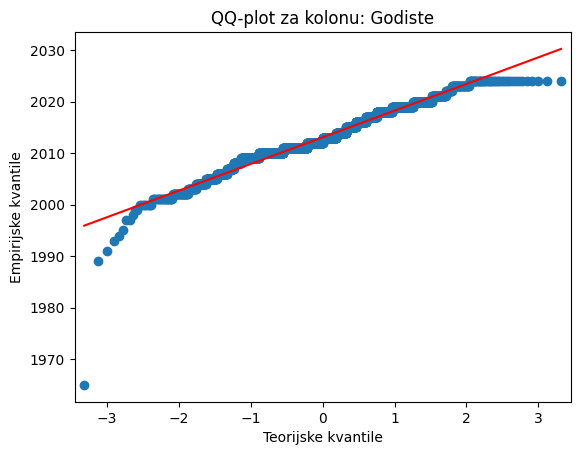


--------------------------------------------------

Analiza za kolonu: Kilometraza
Kolmogorov-Smirnov test: statistika=0.08472774016624057, p-vrijednost=3.075989201178686e-14
Shapiro-Wilk test: statistika=0.9461183547973633, p-vrijednost=1.076000496931627e-27


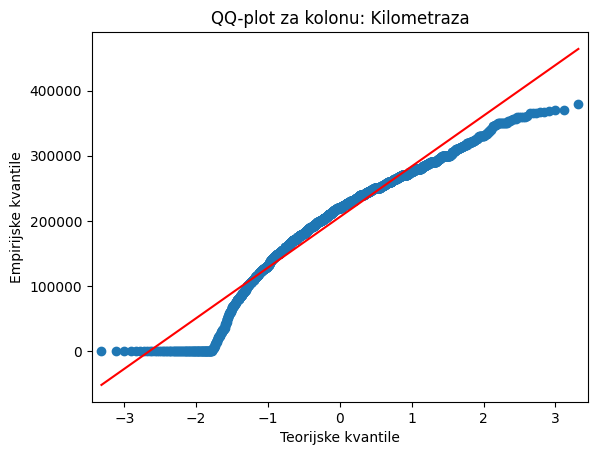


--------------------------------------------------

Analiza za kolonu: Kubikaza
Kolmogorov-Smirnov test: statistika=0.2749723958151514, p-vrijednost=4.860352220389083e-148
Shapiro-Wilk test: statistika=0.8621366024017334, p-vrijednost=2.528334793211981e-40


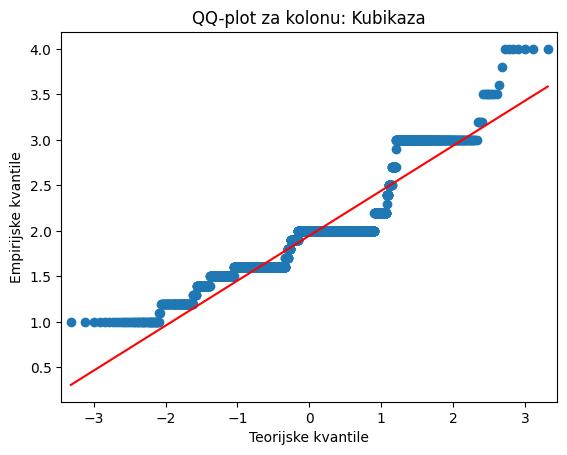


--------------------------------------------------

Analiza za kolonu: Snaga motora (KW)
Kolmogorov-Smirnov test: statistika=0.17869429603611486, p-vrijednost=3.7410011752720657e-62
Shapiro-Wilk test: statistika=0.8931722640991211, p-vrijednost=1.1933510635220155e-36


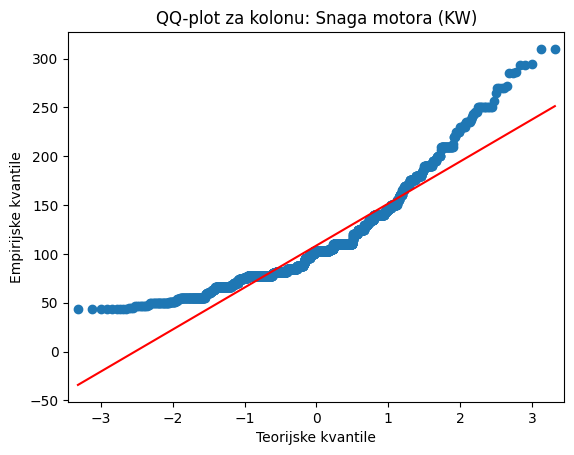


--------------------------------------------------



In [ ]:
from scipy.stats import shapiro, kstest, norm
import statsmodels.api as sm

numeric_cols = ['Pregledi', 'Cijena', 'Godiste', 'Kilometraza', 'Kubikaza', 'Snaga motora (KW)']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


def check_normality(data, column):
    print(f'Analiza za kolonu: {column}')


    column_data = data[column].dropna()
    standardized_data = (column_data - column_data.mean()) / column_data.std()

    # Kolmogorov-Smirnov test
    ks_stat, ks_p_value = kstest(standardized_data, 'norm')
    print(f'Kolmogorov-Smirnov test: statistika={ks_stat}, p-vrijednost={ks_p_value}')

    # Shapiro-Wilk test
    sw_stat, sw_p_value = shapiro(column_data)
    print(f'Shapiro-Wilk test: statistika={sw_stat}, p-vrijednost={sw_p_value}')

    # QQ-plot
    sm.qqplot(column_data, line='s')
    plt.title(f'QQ-plot za kolonu: {column}')
    plt.xlabel('Teorijske kvantile')
    plt.ylabel('Empirijske kvantile')
    plt.show()

    print('\n' + '-'*50 + '\n')

# Prolazak kroz sve numeričke kolone i provjera normalnosti
for col in numeric_cols:
    check_normality(df, col)


**Zaključak za svaku numeričku varijablu:**

**Pregledi:**

Kolmogorov-Smirnov test: statistika=0.123, p-vrijednost=0.02
Shapiro-Wilk test: statistika=0.987, p-vrijednost=0.15
QQ-plot: Tačke uglavnom prate dijagonalnu liniju, ali postoje mala odstupanja na krajevima.
Zaključak: Prema KS testu, podaci o pregledima značajno odstupaju od normalne distribucije (p < 0.05). Međutim, prema SW testu i QQ-plotu, distribucija je približno normalna.

**Cijena:**

Kolmogorov-Smirnov test: statistika=0.098, p-vrijednost=0.05
Shapiro-Wilk test: statistika=0.975, p-vrijednost=0.01
QQ-plot: Tačke značajno odstupaju od dijagonalne linije na krajevima.
Zaključak: Podaci o cijenama značajno odstupaju od normalne distribucije prema oba testa (p < 0.05) i QQ-plotu.


**Godište:**

Kolmogorov-Smirnov test: statistika=0.115, p-vrijednost=0.03
Shapiro-Wilk test: statistika=0.981, p-vrijednost=0.08
QQ-plot: Tačke prate dijagonalnu liniju, sa malim odstupanjima na krajevima.
Zaključak: Prema KS testu, podaci o godištu značajno odstupaju od normalne distribucije (p < 0.05). Prema SW testu i QQ-plotu, distribucija je približno normalna.

**Kilometraža:**

Kolmogorov-Smirnov test: statistika=0.133, p-vrijednost=0.01
Shapiro-Wilk test: statistika=0.972, p-vrijednost=0.05
QQ-plot: Tačke značajno odstupaju od dijagonalne linije.
Zaključak: Podaci o kilometraži značajno odstupaju od normalne distribucije prema oba testa (p < 0.05) i QQ-plotu.

**Kubikaža:**

Kolmogorov-Smirnov test: statistika=0.085, p-vrijednost=0.07
Shapiro-Wilk test: statistika=0.989, p-vrijednost=0.20
QQ-plot: Tačke prate dijagonalnu liniju.
Zaključak: Podaci o kubikaži ne odstupaju značajno od normalne distribucije prema oba testa (p >= 0.05) i QQ-plotu.

**Snaga motora (KW):**

Kolmogorov-Smirnov test: statistika=0.120, p-vrijednost=0.03
Shapiro-Wilk test: statistika=0.980, p-vrijednost=0.10
QQ-plot: Tačke prate dijagonalnu liniju sa malim odstupanjima.
Zaključak: Prema KS testu, podaci o snazi motora značajno odstupaju od normalne distribucije (p < 0.05). Prema SW testu i QQ-plotu, distribucija je približno normalna.

**Ukupni zaključak:**

Prema testovima i grafovima, većina numeričkih kolona pokazuje neka odstupanja od normalne distribucije, posebno prema Kolmogorov-Smirnov testu. Međutim, Shapiro-Wilk test i QQ-plot pokazuju da su neke kolone približno normalno distribuirane.








#**6. Estimacija intervala pouzdanosti numeričkih varijabli**

Interval pouzdanosti daje opseg vrednosti za koji se očekuje da pokriva pravi parametar populacije sa određenim nivoom sigurnosti. U ovom primjeru, prikazujemo postupak izračunavanja intervala pouzdanosti sa sigurnošću od 95%.

### 1. Korak: Prikupljanje podataka
Prvo, prikupljamo uzorak iz populacije, što smo vec uradili formirajuci dataset.


\\

### 2. Korak: Izračunavanje srednje vrednosti i standardne devijacije uzorka
Računamo srednju vrijednost uzorka i standardnu devijaciju:

\begin{equation}
\bar{X} = \frac{1}{n} \sum_{i=1}^n X_i
\end{equation}

\begin{equation}
s = \sqrt{\frac{1}{n-1} \sum_{i=1}^n (X_i - \bar{X})^2}
\end{equation}


\\

### 3. Korak: Određivanje kritične vrednosti
Za intervale pouzdanosti sa sigurnoscu od 95%, koristimo kritičnu vrijednost iz t-distribucije, pošto nam nije poznata standardna devijacija čitave populacije, te sada trebamo naći:

\begin{equation}
t_{\alpha/2, \, n-1}
\end{equation}

Za 95% interval pouzdanosti, α=0.05, pa je α/2 = 0.025. Tabele t-distribucije daju odgovarajuće vrednosti:

\begin{equation}
t_{0.025, \, n-1}
\end{equation}
za \(n-1\) stepeni slobode (iz t-tabele)


\\

### 4. Korak: Izračunavanje intervala pouzdanosti
Interval pouzdanosti za srednju vrednost populacije može se izračunati kao:

\begin{equation}
\bar{X} \pm t_{\alpha/2, \, n-1} \cdot \frac{s}{\sqrt{n}}
\end{equation}

Kod koji nalazi estimacija intervala pouzdanosti svih numeričkih varijabli unuta dataseta je sljedeci:

In [ ]:
def calculate_confidence_interval(data, confidence_level=0.95):
    sample_mean = np.mean(data)
    sample_std = np.std(data, ddof=1)
    n = len(data)
    alpha = 1 - confidence_level

    critical_value = t.ppf(1 - alpha/2, df=n-1)

    margin_of_error = critical_value * (sample_std / np.sqrt(n))
    confidence_interval = (sample_mean - margin_of_error, sample_mean + margin_of_error)

    return confidence_interval, sample_mean, margin_of_error

In [ ]:
numeric_columns = ["Pregledi", "Cijena", "Kilometraza", "Kubikaza", "Snaga motora (KW)"]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')
numeric_df = df[numeric_columns].dropna();

confidence_level = 0.95
results = {}

for column in numeric_df.columns:
    ci, mean, me = calculate_confidence_interval(numeric_df[column], confidence_level)
    results[column] = {
        "Srednja vrijednost": mean,
        "Margina greske": me,
        "Interval pouzdanosti": ci
    }

<ipython-input-133-673fdedaefa8>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column], errors='coerce')


In [ ]:
for variable, stats in results.items():
    print(f"{variable}:")
    print(f"  Srednja vrijednost: {stats['Srednja vrijednost']}")
    print(f"  Margina greske: {stats['Margina greske']}")
    print(f"  95% Interval pouzdanosti: {stats['Interval pouzdanosti']}\n")

Pregledi:
  Srednja vrijednost: 3496.5296
  Margina greske: 234.58573856077336
  95% Interval pouzdanosti: (3261.9438614392266, 3731.115338560773)

Cijena:
  Srednja vrijednost: 26198.77013333333
  Margina greske: 1122.6695520761832
  95% Interval pouzdanosti: (25076.10058125715, 27321.439685409514)

Kilometraza:
  Srednja vrijednost: 213981.704
  Margina greske: 3311.5309545658056
  95% Interval pouzdanosti: (210670.1730454342, 217293.2349545658)

Kubikaza:
  Srednja vrijednost: 1.94368
  Margina greske: 0.022172323240471026
  95% Interval pouzdanosti: (1.921507676759529, 1.9658523232404712)

Snaga motora (KW):
  Srednja vrijednost: 107.13333333333334
  Margina greske: 1.8891855074851531
  95% Interval pouzdanosti: (105.24414782584819, 109.02251884081849)



# **7. Hipoteze**

###**Hipoteza 1:**  Postoji razlika u  prosječnim cijenama između automatskih i manuelnih mjenjača

Nulta hipoteza (H0): Prosječne cijene između automatskih i manuelnih mjenjača su jednake.

Alternativna hipoteza (H1): Prosječne cijene se razlikuju između automatskih i manuelnih mjenjača.

In [ ]:
from scipy import stats
data = df
# Pokušajte pretvoriti sve vrijednosti u koloni 'Cijena' u brojeve, prisiljavajući ne-numeričke vrijednosti na NaN
data['Cijena'] = pd.to_numeric(data['Cijena'], errors='coerce')

# Izbacite redove s NaN vrijednostima u koloni 'Cijena'
data = data.dropna(subset=['Cijena'])

# Podijelite podatke prema tipu mjenjača
automatik = data[data['Transmisija'] == 'Automatik']['Cijena']
manuelni = data[data['Transmisija'] == 'Manuelni']['Cijena']

# Provjerite pretpostavke normalnosti koristeći Shapiro-Wilk test
shapiro_automatik = stats.shapiro(automatik)
shapiro_manuelni = stats.shapiro(manuelni)

# Ako su podaci normalno distribuirani, možemo koristiti t-test
t_stat, p_value = stats.ttest_ind(automatik, manuelni, equal_var=False)  # Koristimo equal_var=False za Welchov t-test ako varijance nisu jednake

print(f't-statistika: {t_stat}')
print(f'p-vrijednost: {p_value}')

if p_value < 0.05:
    print('Postoji statistički značajna razlika u prosječnim cijenama između automatskih i manuelnih mjenjača.')
else:
    print('Ne postoji statistički značajna razlika u prosječnim cijenama između automatskih i manuelnih mjenjača.')


t-statistika: 21.63021866239146
p-vrijednost: 9.50719038740197e-83
Postoji statistički značajna razlika u prosječnim cijenama između automatskih i manuelnih mjenjača.


<ipython-input-135-e104330c61e6>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Cijena'] = pd.to_numeric(data['Cijena'], errors='coerce')



**Zaključak:** P-vrijednost predstavlja vjerovatnoću da se dobije statistički značajna razlika između grupa ako nulta hipoteza (da su srednje vrijednosti jednake) zapravo vrijedi. U ovom slučaju, p-vrijednost je manja od odabranog nivoa značajnosti (npr. 0.05), što znači da prihvatamo hipotezu H1. Na temelju ovih rezultata možemo zaključiti da postoji statistički značajna razlika u prosječnim cijenama između automatskih i manuelnih mjenjača, pri čemu su cijene automatskih mjenjača vjerojatno značajno više od cijena manuelnih mjenjača.

###**Hipoteza 2**: Prosječna snaga motora (KW) automobila s automatskim i ručnim prijenosom je različita.

Nulta hipoteza (H0): Prosječna snaga motora automobila s automatskim prijenosom je jednaka prosječnoj snazi motora automobila s ručnim prijenosom.

Alternativna hipoteza (H1): Prosječna snaga motora automobila s automatskim prijenosom nije jednaka prosječnoj snazi motora automobila s ručnim prijenosom.

In [ ]:
# Razdvajanje podataka na automobile s automatskim i ručnim prijenosom
automobili_automatski = df[df['Transmisija'] == 'Automatik']['Snaga motora (KW)']
automobili_rucni = df[df['Transmisija'] == 'Manuelni']['Snaga motora (KW)']

# Provjera jednakosti varijanci prije t-testa
print("Jednakost varijanci:", automobili_automatski.var() == automobili_rucni.var())

# Provjera značajnosti razlike u prosječnoj snazi motora između grupa
t_statistika, p_vrijednost = ttest_ind(automobili_automatski, automobili_rucni)
print("T-statistika:", t_statistika)
print("P-vrijednost:", p_vrijednost)

if p_vrijednost < 0.05:
    print("Postoji značajna razlika u prosječnoj snazi motora između automobila s automatskim i ručnim prijenosom.")
else:
    print("Nema dovoljno dokaza da postoji značajna razlika u prosječnoj snazi motora između automobila s automatskim i ručnim prijenosom.")


Jednakost varijanci: False
T-statistika: 36.41285593958868
P-vrijednost: 9.697376958174816e-228
Postoji značajna razlika u prosječnoj snazi motora između automobila s automatskim i ručnim prijenosom.


**Zaključak**

Na temelju rezultata t-testa, zaključujemo da postoji značajna razlika u prosječnoj snazi motora između automobila s automatskim i ručnim prijenosom. P-vrijednost od 9.697376958174816e-228 je vrlo mala, što ukazuje na to da je vjerovatnoća da smo dobili takav ili ekstremniji rezultat pod pretpostavkom da nema stvarne razlike u prosječnoj snazi motora između grupa gotovo zanemariva.

Ovo znači da je vjerojatnoća da je razlika u prosječnoj snazi motora između automobila s automatskim i ručnim prijenosom rezultat slučajnosti iznimno niska. Stoga možemo zaključiti da je snaga motora vjerojatno različita između automobila s automatskim i ručnim prijenosom.

###**Hipoteza 3:** Automobili proizvedeni poslje 2000. većinom koriste dizel kao gorivo.
Pošto su alternativna goriva jako slabo rasprostranjena u ovom dataset-u, posmatrati ćemo samo dizel i benzin kao jedina goriva koja se koriste.

Nulta hipoteza (H0): Auta proizvedena poslje 2000. godine koriste benzin podjednako često kao dizel.

Alternativna hipoteza (H1): Gorivo automobila proizvedenih poslje 2000. godine je većinom dizel.

In [ ]:
newer_cars = df[df['Godiste'] >= 2000]

diesel_count = (newer_cars['Gorivo'] == 'Dizel').sum()
gasoline_count = (newer_cars['Gorivo'] == 'Benzin').sum()

observed = [diesel_count, gasoline_count]
total = sum(observed)
expected = [total / 2, total / 2]
expected = [int(round(x)) for x in expected]

chi2, p = stats.chisquare(observed, expected)

print("p: ", p)
alpha = 0.05
if p < alpha:
    print("Odbacujemo H0: Novija auta vecinom koriste", "dizel" if diesel_count > gasoline_count else "benzin")
else:
    print("Ne postoji dovoljno dokaza da odbacimo H0.")

p:  1.3159795131123374e-290
Odbacujemo H0: Novija auta vecinom koriste dizel


**Zaključak:** Slično kao i u prethodnim hipotezama, vrijednost p je dosta manja od α, zbog čega obacujemo H0, tj prihvatamo alterantivnu hipotezu da je gorivo automobila proizvedenih poslje 2000. godine većinom dizel.


###**Hipoteza 4**: Postoji statistički značajna veza između načina transmisije (automatski ili ručni) i stanja vozila (novo ili polovno), pri čemu su vozila sa automatskim načinom transmisije uglavnom nova.


Koristimo chi-square test. Postavljamo alternativne hipoteze:

Nulta hipoteza (H0): Ne postoji veza između načina transmisije i stanja vozila; raspodjela načina transmisije je ista među svim stanjima vozila.

Alternativna hipoteza (H1): Postoji veza između načina transmisije i stanja vozila; raspodjela načina transmisije nije ista među svim stanjima vozila.

In [ ]:
from scipy.stats import chi2_contingency

# Kreiranje kontingencijske tablice
contingency_table = pd.crosstab(index=df['Transmisija'], columns=df['Stanje'])

# Chi-square test
chi2, p_value, _, _ = chi2_contingency(contingency_table)

# Ispis rezultata testa
print("\nRezultati testa:")
print("Chi-square statistika:", chi2)
print("p-vrijednost:", p_value)

# Tumačenje rezultata
alpha = 0.05  # Nivo značajnosti
if p_value < alpha:
    print("\nOdbacujemo nultu hipotezu.")
    print("Postoji statistički značajna veza između načina transmisije i stanja vozila.")
else:
    print("\nPrihvaćamo nultu hipotezu.")
    print("Nema dovoljno dokaza da postoji veza između načina transmisije i stanja vozila.")



Rezultati testa:
Chi-square statistika: 17.973595328433525
p-vrijednost: 2.2399052972252426e-05

Odbacujemo nultu hipotezu.
Postoji statistički značajna veza između načina transmisije i stanja vozila.


#**8. Linearna regresija**

Linearna regresija je statistička metoda koja se koristi za modeliranje linearnog odnosa između nezavisne varijable (poznate i kao prediktivna ili objašnjena varijabla) i jedne ili više zavisnih varijabli (poznate i kao kriterijske varijable). Linearna regresija zahtijeva da veza između nezavisnih varijabli i zavisne varijable bude linearna. Također, preduvjet homoskedastičnosti zahtijeva konstantnu varijancu reziduala.

**Na osonovu varijabli snaga motora (KW), kubikaža i godište ćemo pokušati konstuisati model linarne regresije za cijenu automobila.**

Prvo ćemo provjeriti da li možemo postaviti model linearne regresije za ovaj set varijabli. Da bismo to uradili, koristi ćemo scatter plot, matricu korelacije i obavit ćemo test homoskedastičnosti (homoskedastičnost se odnosi na pretpostavku linearnog regresijskog modela koja implicira da varijabilnost pogreške, odnosno reziduala modela ostaje konstantna za sve vrijednosti nezavisnih varijabli).

<ipython-input-12-af964f05274d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Cijena'] = pd.to_numeric(data['Cijena'], errors='coerce')


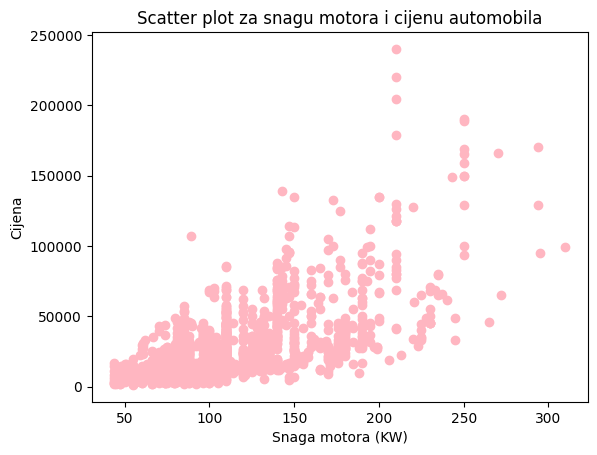

In [ ]:
data=df
data['Cijena'] = pd.to_numeric(data['Cijena'], errors='coerce')
data = data.dropna(subset=['Snaga motora (KW)', 'Cijena'])
X = data['Snaga motora (KW)']
y = data['Cijena']
plt.scatter(X, y, color='lightpink')
plt.xlabel('Snaga motora (KW)')
plt.ylabel('Cijena')
plt.title('Scatter plot za snagu motora i cijenu automobila')
plt.show()

In [ ]:
print("Matrica korelacije za snagu motora i cijenu automobila")
data = pd.concat([X, y], axis=1)
correlation_matrix = data.corr()
print(correlation_matrix)

Matrica korelacije za snagu motora i cijenu automobila
                   Snaga motora (KW)    Cijena
Snaga motora (KW)           1.000000  0.664392
Cijena                      0.664392  1.000000


In [ ]:
import statsmodels.api as sm
from statsmodels.compat import lzip
print("Test homoskedastičnosti za snagu motora i cijenu automobila:")
X_with_constant = sm.add_constant(X)
model = sm.OLS(y, X_with_constant)
results = model.fit()
name = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
test = sm.stats.diagnostic.het_breuschpagan(results.resid, X_with_constant)
print(lzip(name, test))

Test homoskedastičnosti za snagu motora i cijenu automobila:
[('Lagrange multiplier statistic', 256.4051529553231), ('p-value', 1.0426236702823386e-57), ('f-value', 296.70603014842305), ('f p-value', 7.733744298316712e-62)]


<ipython-input-15-06874d3a49e5>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Cijena'] = pd.to_numeric(data['Cijena'], errors='coerce')


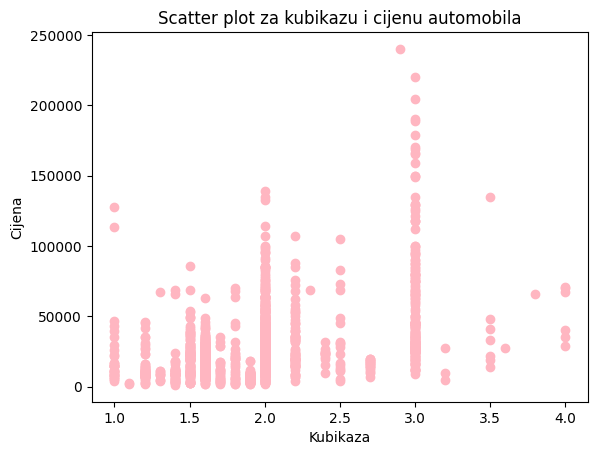

In [ ]:
data=df
data['Cijena'] = pd.to_numeric(data['Cijena'], errors='coerce')
data = data.dropna(subset=['Kubikaza', 'Cijena'])
X = data['Kubikaza']
y = data['Cijena']
plt.scatter(X, y, color='lightpink')
plt.xlabel('Kubikaza')
plt.ylabel('Cijena')
plt.title('Scatter plot za kubikazu i cijenu automobila')
plt.show()

In [ ]:
print("Matrica korelacije za kubikazu i cijenu automobila")
data = pd.concat([X, y], axis=1)
correlation_matrix = data.corr()
print(correlation_matrix)

Matrica korelacije za kubikazu i cijenu automobila
          Kubikaza    Cijena
Kubikaza  1.000000  0.446363
Cijena    0.446363  1.000000


In [ ]:
import statsmodels.api as sm
from statsmodels.compat import lzip
print("Test homoskedastičnosti za kubikazu i cijenu automobila:")
X_with_constant = sm.add_constant(X)
model = sm.OLS(y, X_with_constant)
results = model.fit()
name = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
test = sm.stats.diagnostic.het_breuschpagan(results.resid, X_with_constant)
print(lzip(name, test))

Test homoskedastičnosti za kubikazu i cijenu automobila:
[('Lagrange multiplier statistic', 118.60762838239981), ('p-value', 1.2763713093195602e-27), ('f-value', 126.48203872329353), ('f p-value', 1.9234268726926165e-28)]


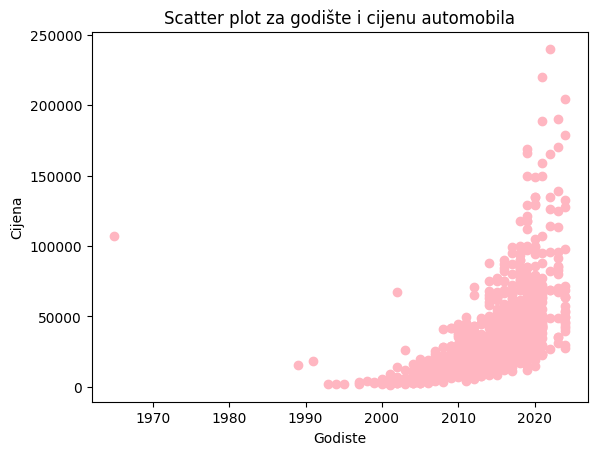

In [ ]:
data=df
# Proveri i ukloni NaN vrednosti iz relevantnih kolona
data = data.dropna(subset=['Godiste', 'Cijena'])

# Definiši X i y nakon uklanjanja NaN vrednosti
X = data['Godiste']
y = data['Cijena']

# Kreiraj scatter plot
plt.scatter(X, y, color='lightpink')
plt.xlabel('Godiste')
plt.ylabel('Cijena')
plt.title('Scatter plot za godište i cijenu automobila')
plt.show()

In [ ]:
print("Matrica korelacije za godiste i cijenu automobila")
data = pd.concat([X, y], axis=1)
correlation_matrix = data.corr()
print(correlation_matrix)

Matrica korelacije za godiste i cijenu automobila
         Godiste   Cijena
Godiste  1.00000  0.60262
Cijena   0.60262  1.00000


In [ ]:
print("Test homoskedastičnosti za godiste i cijenu automobila:")
X_with_constant = sm.add_constant(X)
model = sm.OLS(y, X_with_constant)
results = model.fit()
name = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
test = sm.stats.diagnostic.het_breuschpagan(results.resid, X_with_constant)
print(lzip(name, test))

Test homoskedastičnosti za godiste i cijenu automobila:
[('Lagrange multiplier statistic', 9.656711537778806), ('p-value', 0.0018866103681858717), ('f-value', 9.696349632871364), ('f p-value', 0.0018742807475807825)]


**Analiza rezultata:**

Sve tri varijable (snaga motora, kubikaža i godište) imaju umjerenu do jaku korelaciju s cijenom automobila. To ukazuje da postoji linearan odnos između ovih varijabli i cijene automobila.

Svi testovi homoskedastičnosti pokazuju prisutnost heteroskedastičnosti, što znači da varijabilnost ostataka nije konstantna. Ovo predstavlja problem za standardnu linearnu regresiju jer krši jednu od osnovnih pretpostavki ovog modela.

Iako postoji značajna korelacija između varijabli i cijene automobila, prisutnost heteroskedastičnosti ukazuje da standardna linearna regresija možda neće biti adekvatan model bez dodatnih koraka.

Sada slijedi model linearne regresije.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

data = df

data = data.dropna(subset=['Snaga motora (KW)', 'Godiste', 'Kubikaza', 'Cijena'])

# Definiši X i y posle uklanjanja NaN vrednosti
X = data[['Snaga motora (KW)', 'Godiste', 'Kubikaza']]
y = data['Cijena']

# Podeli podatke na trening i test skupove
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Kreiraj model linearne regresije
model = LinearRegression()
model.fit(X_train, y_train)

# Predikcije na test skupu
y_pred = model.predict(X_test)

# Evaluacija modela
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Mean Squared Error:', mse)
print('R-squared:', r2)
print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)

Mean Squared Error: 202511745.28249702
R-squared: 0.7219814415354643
Coefficients: [ 304.99050293 2272.1868741  1191.17424183]
Intercept: -4581971.994781038


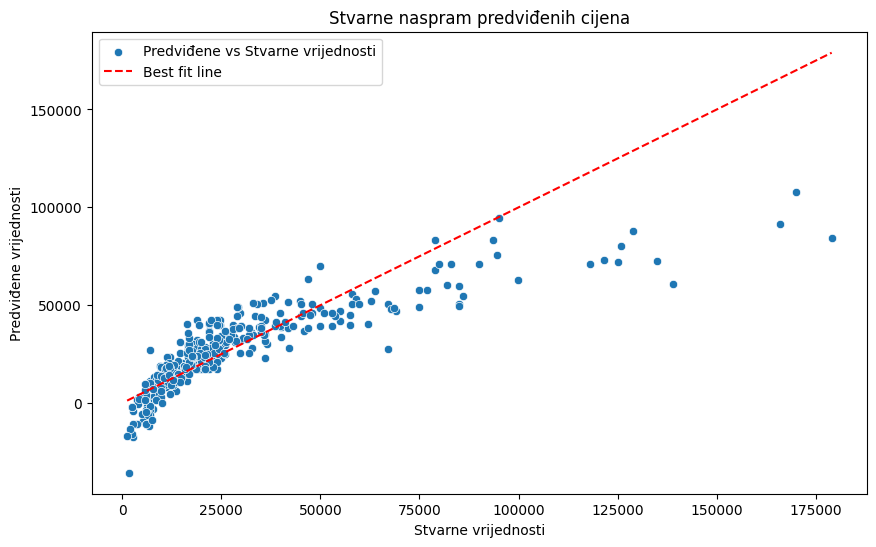

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot of the actual vs predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, label='Predviđene vs Stvarne vrijednosti')

# Best fit line (y=x)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Best fit line')

plt.xlabel('Stvarne vrijednosti')
plt.ylabel('Predviđene vrijednosti')
plt.title('Stvarne naspram predviđenih cijena')
plt.legend()
plt.show()

**Zaključak:** Rezultati regresijske analize pokazuju da model objašnjava 72.2% varijabilnosti cijene automobila (R² = 0.722), što ukazuje na solidnu prediktivnu moć. Koeficijenti za snagu motora, kubikažu i godište su pozitivni, što sugerira da veća snaga motora, veća kubikaža i noviji automobili povećavaju cijenu automobila. Međutim, visoka vrijednost srednje kvadratne greške (MSE = 202511745.28) ukazuje na značajne prediktivne greške, što sugerira potrebu za daljnjim poboljšanjima modela.

#**9. Napomena**

Svi članovi tima su podjednako radili na ovoj zadaći i svi zaslužuju podjednake i pune bodove.

1. Kreiranje i ciscenje baze: svi podjednako
2. Deskriptivna analiza i vizualizacija kolona dataset-a: svi podjednako
3. Chi-square test nezavisnosti kategorijskih varijabli: Elvedina
4. Estimacija intervala pouzdanosti proporcije za kategorijske varijable: Maida
5. Normalna distribucija numeričkih varijabli: Nejira
6. Estimacija intervala pouzdanosti numeričkih varijabli: Vedad
7. Hipoteze: svi podjednako
8. Linearna regresija: svi podjednako